## ViT

In [2]:
import torch
from PIL import Image
from torchvision.models import vision_transformer

from zennit.image import imgify
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from lxt.efficient import monkey_patch, monkey_patch_zennit

monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward


In [3]:
from io import BytesIO
import requests

def get_vit_imagenet(device="cuda"):
    """
    Load a pre-trained Vision Transformer (ViT) model with ImageNet weights.

    Parameters:
    device (str): Device to load the model on ('cuda' or 'cpu')

    Returns:
    tuple: (model, weights) - The ViT model and its pre-trained weights
    """
    weights =vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval()
    model.to(device)

    # Deactivate gradients on parameters to save memory
    for param in model.parameters():
        param.requires_grad = False

    return model, weights

# Load the pre-trained ViT model
model_vit, weights = get_vit_imagenet()

# Load and preprocess the input image
image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")
input_tensor = weights.transforms()(image).unsqueeze(0).to("cuda")

In [31]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [5]:
model_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [6]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [7]:
# Define rules for the Conv2d and Linear layers using 'zennit'
conv_gamma = 100
lin_gamma = 0.05
# LayerMapComposite maps specific layer types to specific LRP rule implementations
zennit_comp = LayerMapComposite([
    (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
    (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
])

# Register the composite rules with the model_vit
zennit_comp.register(model_vit)

# Forward pass with gradient tracking enabled
y = model_vit(input_tensor.requires_grad_())

# Get the top 5 predictions
_, top5_classes = torch.topk(y, 5, dim=1)
top5_classes = top5_classes.squeeze(0).tolist()

# Get the class labels
labels = weights.meta["categories"]
top5_labels = [labels[class_idx] for class_idx in top5_classes]

# Print the top 5 predictions and their labels
for i, class_idx in enumerate(top5_classes):
    print(f'Top {i+1} predicted class: {class_idx}, label: {top5_labels[i]}')

# Backward pass for the highest probability class
# This initiates the LRP computation through the network
y[0, top5_classes[0]].backward()

# Remove the registered composite to prevent interference in future iterations
zennit_comp.remove()

# Calculate the relevance by computing Input*Gradient
# This is the final step of LRP to get the pixel-wise explanation
heatmap = (input_tensor * input_tensor.grad).sum(1)

# Normalize relevance between [-1, 1] for plotting
heatmap = heatmap / abs(heatmap).max()

Top 1 predicted class: 176, label: Saluki
Top 2 predicted class: 250, label: Siberian husky
Top 3 predicted class: 207, label: golden retriever
Top 4 predicted class: 248, label: Eskimo dog
Top 5 predicted class: 208, label: Labrador retriever


In [8]:
heatmap.shape

torch.Size([1, 224, 224])

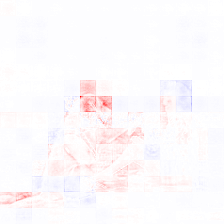

In [9]:
imgify(heatmap.detach().cpu().numpy(), vmin=-1, vmax=1)

## Qwen 3

In [1]:
import torch
from transformers import AutoTokenizer
from transformers.models.qwen3 import modeling_qwen3
from transformers import BitsAndBytesConfig

from lxt.efficient import monkey_patch
from lxt.utils import pdf_heatmap, clean_tokens

# modify the Qwen3 module to compute LRP in the backward pass
monkey_patch(modeling_qwen3, verbose=True)

# optional 4bit quantization 
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

path = 'Qwen/Qwen3-1.7B'
model = modeling_qwen3.Qwen3ForCausalLM.from_pretrained(path,
                                                        device_map='auto',
                                                        dtype=torch.bfloat16,
                                                        quantization_config=quantization_config)


tokenizer = AutoTokenizer.from_pretrained(path)

prompt = """Context: Mount Everest attracts many climbers, including highly experienced mountaineers. There are two main climbing routes, one approaching the summit from the southeast in Nepal (known as the standard route) and the other from the north in Tibet. While not posing substantial technical climbing challenges on the standard route, Everest presents dangers such as altitude sickness, weather, and wind, as well as hazards from avalanches and the Khumbu Icefall. As of November 2022, 310 people have died on Everest. Over 200 bodies remain on the mountain and have not been removed due to the dangerous conditions. The first recorded efforts to reach Everest's summit were made by British mountaineers. As Nepal did not allow foreigners to enter the country at the time, the British made several attempts on the north ridge route from the Tibetan side. After the first reconnaissance expedition by the British in 1921 reached 7,000 m (22,970 ft) on the North Col, the 1922 expedition pushed the north ridge route up to 8,320 m (27,300 ft), marking the first time a human had climbed above 8,000 m (26,247 ft). The 1924 expedition resulted in one of the greatest mysteries on Everest to this day: George Mallory and Andrew Irvine made a final summit attempt on 8 June but never returned, sparking debate as to whether they were the first to reach the top. Tenzing Norgay and Edmund Hillary made the first documented ascent of Everest in 1953, using the southeast ridge route. Norgay had reached 8,595 m (28,199 ft) the previous year as a member of the 1952 Swiss expedition. The Chinese mountaineering team of Wang Fuzhou, Gonpo, and Qu Yinhua made the first reported ascent of the peak from the north ridge on 25 May 1960. \
Question: How high did they climb in 1922? According to the text, the 1922 expedition reached 8,"""

inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(model.device)
input_ids = inputs.input_ids


/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched Qwen3MLP
Patched Qwen3RMSNorm
Patched Dropout
Patched transformers.models.qwen3.modeling_qwen3


Loading checkpoint shards: 100%|██████████| 2/2 [00:03<00:00,  1.59s/it]


In [2]:

attention_mask = inputs.attention_mask

with torch.no_grad():
    generated_ids = model.generate(input_ids=input_ids, attention_mask=attention_mask)
# tokenizer.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]


In [3]:
generated_ids.shape

torch.Size([1, 476])

In [ ]:

gen_ids = generated_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

tokenizer.batch_decode(gen_ids, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'320 m (27,300 ft). The answer is...?\nA)'

In [6]:
L_gen = gen_ids.size(1)

# positions whose logits predict each generated token
indices = torch.arange(
    ctx_len - 1,
    ctx_len - 1 + L_gen,
    device=model.device
)  # shape [L_gen]


In [9]:
L_gen = gen_ids.size(1)
L_gen

20

In [12]:
# # optional gradient checkpointing to save memory (2x forward pass)
# model.train()
# model.gradient_checkpointing_enable()

# deactive gradients on parameters to save memory
for param in model.parameters():
    param.requires_grad = False


# get input embeddings so that we can compute gradients w.r.t. input embeddings
input_ids = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).input_ids.to(model.device)
# input_embeds = model.get_input_embeddings()(input_ids)
input_embeds = model.get_input_embeddings()(generated_ids)

# inference and get the maximum logit at the last position (we can also explain other tokens)
output_logits = model(inputs_embeds=input_embeds.requires_grad_(), use_cache=False).logits


In [13]:
output_logits.shape

torch.Size([1, 476, 151936])

In [14]:
selected_logits = output_logits[0, indices, gen_ids[0]]   # [L_gen]

selected_logits.backward(torch.ones_like(selected_logits))
# equivalently: selected_logits.sum().backward()


In [35]:
# max_logits, max_indices = torch.max(output_logits[0, -1, :], dim=-1)

# # Backward pass (the relevance is initialized with the value of max_logits)
# # This initiates the LRP computation through the network
# max_logits.backward()

# obtain relevance by computing Input * Gradient
relevance = (input_embeds * input_embeds.grad).float().sum(-1).detach().cpu()[0] # cast to float32 before summation for higher precision

# normalize relevance between [-1, 1] for plotting
#relevance = relevance / relevance.abs().max()

In [16]:
# remove special characters from token strings and plot the heatmap
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens = clean_tokens(tokens)

# pdf_heatmap(tokens, relevance, path='qwen3_1.7B_heatmap.pdf', backend='xelatex') # backend='xelatex' supports more characters

# # plot again without first token, because it receives large relevance values overshadowing the rest
# pdf_heatmap(tokens[1:], relevance[1:] / relevance[1:].max(), path='qwen3_1.7B_heatmap_wo_first.pdf', backend='xelatex')

In [36]:
prompt_relevance = relevance[:ctx_len]
prompt_tokens = tokenizer.convert_ids_to_tokens(generated_ids[0, :ctx_len])
prompt_tokens = clean_tokens(prompt_tokens)



In [37]:
import numpy as np
import matplotlib

def _apply_colormap(relevance, cmap_name="bwr"):
    """
    Map a scalar relevance in [-1, 1] to an RGB triplet in [0, 1].
    """
    # normalize from [-1, 1] to [0, 1]
    v = (relevance + 1.0) / 2.0
    v = np.clip(v, 0.0, 1.0)

    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    r, g, b, _ = cmap(v)
    return r, g, b


def _escape_html(text: str) -> str:
    return (
        text.replace("&", "&amp;")
            .replace("<", "&lt;")
            .replace(">", "&gt;")
    )

def _generate_html(words, relevances, cmap="bwr"):
    """
    Generate HTML code for a sentence with colored words based on their relevances.
    """
    html = []
    html.append("<!DOCTYPE html>")
    html.append("<html>")
    html.append("<head>")
    html.append('<meta charset="utf-8">')
    html.append("<style>")
    html.append("""
    body {
        font-family: sans-serif;
        max-width: 900px;
        line-height: 1.6;
        padding: 1rem;
    }
    .token {
        padding: 2px 3px;
        margin: 1px 1px;
        display: inline-block;
        font-family: monospace;
        border-radius: 2px;
    }
    """)
    html.append("</style>")
    html.append("</head>")
    html.append("<body>")

    for word, relevance in zip(words, relevances):
        r, g, b = _apply_colormap(float(relevance), cmap)
        R, G, B = int(r * 255), int(g * 255), int(b * 255)

        word_html = _escape_html(word)
        html.append(
            f'<span class="token" '
            f'style="background-color: rgb({R},{G},{B});">'
            f'{word_html}</span>'
        )

    html.append("</body>")
    html.append("</html>")

    return "\n".join(html)


In [38]:
def html_heatmap(words, relevances, path="heatmap.html", cmap="bwr"):
    """
    Write an HTML file with colored tokens according to relevance.
    No LaTeX, no external dependencies beyond matplotlib (for colormap).
    """
    html_code = _generate_html(words, relevances, cmap=cmap)

    with open(path, "w", encoding="utf-8") as f:
        f.write(html_code)

    print(f"Saved HTML heatmap to: {path}")
    return path


In [39]:
from IPython.display import HTML, display


# html_heatmap(prompt_tokens, prompt_relevance,
#             path='qwen3_1.7B_prediction_heatmap.html')
html_code = _generate_html(prompt_tokens, prompt_relevance, cmap="bwr")
display(HTML(html_code))

## Captum LLM

In [1]:
from huggingface_hub import login
login()

In [1]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        #device_map="auto",
        max_memory={"cuda:0": "20GiB", "cpu": "48GiB"},
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear4bit(in_features=1280, out_features=3840, bias=True)
            (proj): Linear4bit(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear4bit(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear4bit(in_features=3420, out_features=1280, bias=True)
        

In [3]:
torch.cuda.empty_cache()

In [4]:
from abc import abstractmethod
from typing import Union
from torch import nn

class HF_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                image_grid_thw):

        # Vision embeddings
        image_embeds = model.get_image_features(pixel_values,
                                                image_grid_thw=image_grid_thw)
        
        image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
        image_mask, _ = model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_embeds
        )
        inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"]
        del outputs
        return logits


    # --------- device helpers ---------

    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "HF_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


In [5]:
from captum.attr import (
    LLMGradientAttribution, 
    TextTokenInput,
    InputXGradient,
    TokenReferenceBase,
    visualization
)

In [6]:
hf_model = HF_Wrapper(model, processor)

In [20]:
ig.model

AttributeError: 'InputXGradient' object has no attribute 'model'

In [7]:
from PIL import Image
import requests
from io import BytesIO

def get_inputs(processor, dtype=torch.bfloat16):
    image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
    image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                # {"type": "text", "text": "Describe the main scene and the object being pointed at."},
                {"type": "text", "text": "What is the color of the dog ?"},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

     # ---- Convert everything that can be bf16 into bf16 ----
    if dtype is not None:
        for k in inputs:
            if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
                inputs[k] = inputs[k].to(dtype=dtype)


    return inputs, image


In [8]:
inputs, image = get_inputs(processor)

In [9]:
inputs = inputs.to(model.device)

In [10]:
def get_target(inputs, model):
    inputs = inputs.to(model.device)
    model.eval()
    with torch.no_grad():

        gen_ids = model.generate(**inputs,
                                max_new_tokens=32,
                                use_cache=False)

    return gen_ids


In [11]:
gen_ids = get_target(inputs, model)

In [12]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)


In [13]:
target_tokens = generated_ids_trimmed[0]

In [14]:

text = hf_model.processor.batch_decode(
                    target_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False
                )

In [15]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [16]:
def get_attributions(inputs, hf_model, attr, target_tokens, plot=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    text_embeds = hf_model.text_embeddings_layer(input_ids).clone().detach()

    captum_forward = (text_embeds, pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids, image_grid_thw)

    # Make a forward and predictions
    captum_args = captum_forward + captum_add_forward

    # logits = hf_model(*captum_args)
    # pred, idx = torch.max(logits[0, -1, :], dim=-1)

    text = hf_model.processor.batch_decode(
                        target_tokens, skip_special_tokens=True, clean_up_tokenization_spaces=False
                    )
    
    baselines = None
    use_baselines = False
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=hf_model.device).unsqueeze(0)
        reference_embeds = hf_model.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)
    
    # Get attributions
    if use_baselines:
        attributions = attr.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=1,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr.attribute(inputs=captum_forward,
                                    target=1,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    # Visualize text attributions
    text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
    text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm



    

    if plot:
        # Visualize text attributions
        # vis_data_records = [visualization.VisualizationDataRecord(
        #                     text_attr,
        #                     pred[0].item(),
        #                     model.config.id2label[idx.item()],
        #                     model.config.id2label[idx.item()],
        #                     target_tokens,
        #                     attributions[0].sum(),       
        #                     text.split(),
        #                     0.0)]
        # visualization.visualize_text(vis_data_records)

        # visualize image attributions
        original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

        # visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
        #                                             ["original_image", "heat_map"], ["all", "all"], 
        #                                             titles=["Original Image", "Attribution Magnitude"],
        #                                             cmap=default_cmap,
        #                                             show_colorbar=True)
    
    return attributions

In [17]:
import sys, gc, torch

gc.collect()
torch.cuda.empty_cache()

In [18]:
torch.cuda.empty_cache()

In [ ]:
ig = InputXGradient(hf_model)

try:
    attributions = get_attributions(inputs, hf_model, ig, target_tokens, plot=False)
except Exception as e:
    print(e)
    for name in ["inputs"]:
        if name in locals():
            del locals()[name]
    gc.collect()
    torch.cuda.empty_cache()

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


In [14]:
baselines = None
use_baselines = False
if use_baselines:
    # Baselines
    token_reference = TokenReferenceBase(reference_token_idx=processor.tokenizer.pad_token_id)
    # generate reference for each sample
    reference_ids = token_reference.generate_reference(
                            input_ids.shape[-1],
                            device=hf_model.device).unsqueeze(0)
    reference_embeds = hf_model.text_embeddings_layer(reference_ids)
    baselines = (reference_embeds, pixel_values * 0.0)

In [ ]:
captum_forward = (text_embeds, pixel_values.requires_grad_())
captum_add_forward = (attention_mask, image_grid_thw)

# Make a forward and predictions
captum_args = captum_forward + captum_add_forward
#logits = hf_model(*captum_args)
#pred, idx = logits.max(dim=1)




/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/captum/attr/_core/input_x_gradient.py:118: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


AssertionError: Target not provided when necessary, cannot take gradient with respect to multiple outputs.

In [22]:
# Get attributions
#if use_baselines:
attributions = ig.attribute(inputs=captum_forward,
                            #baselines=baselines,
                            target=idx,
                            additional_forward_args=captum_add_forward,
                            #n_steps=10
                            )

AssertionError: Target not provided when necessary, cannot take gradient with respect to multiple outputs.

In [ ]:
from typing import List, Optional, Dict, Any
from copy import copy

from captum._utils.typing import TokenizerLike
from captum.attr._utils.attribution import Attribution
import torch
from torch import nn, Tensor
from captum.attr._core.llm_attr import BaseLLMAttribution
from captum.attr._utils.attribution import GradientAttribution


import torch.nn.functional as F


class CaptumLLMAttribution(BaseLLMAttribution):
    def __init__(self, attr_method: GradientAttribution, tokenizer: TokenizerLike) -> None:
        super().__init__(attr_method, tokenizer)

        # shallow copy is enough to avoid modifying original instance
        self.attr_method: GradientAttribution = copy(attr_method)
        self.attr_method.forward_func = CaptumLLMForwardFunc(self)

    def attribute(self,
                  inpts,
                  target: Union[str, List[str], torch.Tensor],
                    use_baselines=True,
                    attr_kwargs: Optional[Dict[str, Any]] = None,
                    ):

        if isinstance(target, torch.Tensor):
            # Move the target to the good device
            target_tokens = target.clone().detach().to(self.device)
        
        else: # isinstance(target, list):
            # Encode the target using the preprocessor
            target_tokens = self.tokenizer(target, return_tensors="pt", add_special_tokens=True).to(self.device)
        


        inpts.to(self.device)
        input_ids = inpts.input_ids
        attention_mask = inpts.attention_mask


        # Call the attrubition method
        attr_list = []
        n_output_tokens = target_tokens.size(0)

        # Get the embeddings
        input_embeds = self.attr_method.model.get_inputs_embeddings(input_ids).clone().detach()

        baselines = None
        # if use_baselines:
        #     # Baselines
        #     token_reference = TokenReferenceBase(reference_token_idx=tokenizer.pad_token_id)
        #     # generate reference for each sample
        #     reference_ids = token_reference.generate_reference(
        #                             input_ids.shape[-1],
        #                             device=model_wrapper.device).unsqueeze(0)
        #     reference_embeds = model_wrapper.vilt.embeddings.text_embeddings.word_embeddings(reference_ids)
        #     baselines = (reference_embeds,)

        for cur_target_idx in range(n_output_tokens):
            
            captum_forward = (input_embeds,)
            captum_add_forward = (attention_mask, target_tokens, cur_target_idx)


            # Get attributions
            if use_baselines:
                attr = self.attr_method.attribute(inputs=captum_forward,
                                            baselines=baselines,
                                            additional_forward_args=captum_add_forward,
                                            **attr_kwargs,
                                            )  
            else:
                attr = self.attr_method.attribute(inputs=captum_forward,
                                            additional_forward_args=captum_add_forward,
                                            **attr_kwargs,
                                            )


            attr = attr.detach()

            # will have the attr for previous output tokens
            # cut to shape(batch_size, inp_len, emb_dim)
            if cur_target_idx:
                attr = attr[:, :-cur_target_idx]

            # the author of IG uses sum
            # https://github.com/ankurtaly/Integrated-Gradients/blob/master/BertModel/bert_model_utils.py#L350
            attr = attr.sum(-1)

            attr_list.append(attr)

        # assume inp batch only has one instance
        # to shape(n_output_token, ...)
        attr = torch.cat(attr_list, dim=0)

        # # grad attr method do not care the length of features in interpretable format
        # # it attributes to all the elements of the output of the specified layer
        # # so we need special handling for the inp type which don't care all the elements
        # if isinstance(inp, TextTokenInput) and inp.itp_mask is not None:
        #     itp_mask = inp.itp_mask.to(attr.device)
        #     itp_mask = itp_mask.expand_as(attr)
        #     attr = attr[itp_mask].view(attr.size(0), -1)

        # for all the gradient methods we support in this class
        # the seq attr is the sum of all the token attr if the attr_target is log_prob,
        # shape(n_input_features)
        seq_attr = attr.sum(0)
        return seq_attr



class CaptumLLMForwardFunc(nn.Module):
    """
    Forward wrapper for Captum, analogous to GradientForwardFunc.

    Inputs:
        text_embeds:    (B, L_in, D)  - embeddings for the *input* tokens
        attention_mask: (B, L_in)     - attention mask for input tokens
        target_tokens:  (L_out,)      - 1D tensor of target token ids
        cur_target_idx: int           - index of current target token

    Optionally:
        pixel_values, pixel_mask, token_type_ids for VLMs (e.g. ViLT).
    """

    def __init__(self, attr: CaptumLLMAttribution) -> None:
        super().__init__()
        self.attr = attr
        self.model = attr.model  # e.g. an HF_Wrapper

    def forward(
        self,
        text_embeds: torch.Tensor,
        attention_mask: torch.Tensor,
        target_tokens: torch.Tensor,
        cur_target_idx: int,
    ) -> torch.Tensor:
        """
        Returns:
            token_log_probs: (B,) log p(target_tokens[cur_target_idx] | input, prefix)
        """
        device = self.model.device
        B, _, _ = text_embeds.shape

        # target_tokens = target_tokens.to(device)

        # --- build teacher-forced prefix for output tokens in embedding space ---
        if cur_target_idx > 0:
            # Prefix token ids: [t_0, ..., t_{k-1}], shape (k,)
            # replicate for all batch samples: (B, k)
            prefix_ids = target_tokens[:cur_target_idx].unsqueeze(0).expand(B, -1).to(device)

            # convert prefix ids to embeddings via the model's text embedding layer
            prefix_embeds = self.model.text_embeddings_layer(prefix_ids)  # (B, k, D)

            # concat along sequence dimension: input tokens + prefix tokens
            new_text_embeds = torch.cat([text_embeds, prefix_embeds], dim=1)  # (B, L_in + k, D)

            # attention mask for prefix (all ones)
            prefix_mask = torch.ones_like(
                prefix_embeds, dtype=attention_mask.dtype, device=device
            )
            new_attention_mask = torch.cat([attention_mask, prefix_mask], dim=1)  # (B, L_in + k)
        else:
            new_text_embeds = text_embeds
            new_attention_mask = attention_mask

        # --- forward through wrapped model ---
        logits = self.model(
            text_embeds=new_text_embeds,
            attention_mask=new_attention_mask,
        )  # expected shape: (B, L_total, vocab_size)

        # we only care about logits at the *last* position (next-token prediction)
        last_logits = logits[:, -1, :]  # (B, vocab_size)
        log_probs = F.log_softmax(last_logits, dim=-1)

        # scalar target token id
        target_token_id = target_tokens[cur_target_idx]
        # pick log-probability of that token for each sample
        token_log_probs = log_probs[..., target_token_id]  # (B,)

        return token_log_probs



In [ ]:
from typing import List, Union, Dict, Any, Optional
import torch
from torch import Tensor
from captum.attr import TokenReferenceBase  # if you use baselines
# from captum.attr import LayerIntegratedGradients  # for construction elsewhere


def captum_llm_attribution(
    inpts,                         # HF BatchEncoding (input_ids, attention_mask, ...)
    target: Union[str, List[str], torch.Tensor],
    model_wrapper,                 # instance of HF_Wrapper (or compatible)
    tokenizer,
    attr_hf,                       # Captum attribution object (e.g. LayerIntegratedGradients)
    use_baselines: bool = True,
    attr_kwargs: Optional[Dict[str, Any]] = None,
    pixel_values: Optional[Tensor] = None,
    pixel_mask: Optional[Tensor] = None,
    token_type_ids: Optional[Tensor] = None,
) -> Dict[str, Any]:
    """
    Compute token- and sequence-level attributions for a given LLM/VLM target.

    Args:
        inpts: HF tokenizer outputs (e.g. tokenizer(prompt, return_tensors="pt")).
        target: target text (str or list of str) or tensor of token ids.
        model_wrapper: your HF_Wrapper-like module with .text_embeddings_layer and .device.
        tokenizer: HF tokenizer.
        attr_hf: Captum attribution instance, whose forward_func should be CaptumLLMForwardFunc(model_wrapper).
        use_baselines: if True, use pad-token embeddings as baseline.
        attr_kwargs: extra kwargs passed to attr_hf.attribute (e.g. n_steps).
        pixel_values, pixel_mask, token_type_ids: for VLM models like ViLT.

    Returns:
        {
          "seq_attr":     Tensor (n_input_tokens,),
          "token_attr":   Tensor (n_output_tokens, n_input_tokens),
          "input_tokens": List[str],
          "output_tokens":List[str],
        }
    """
    if attr_kwargs is None:
        attr_kwargs = {}

    device = model_wrapper.device

    # --- 1. Prepare input tensors on the right device ---
    # HF BatchEncoding supports .to(device), but be sure to reassign.
    inpts = inpts.to(device)
    input_ids: Tensor = inpts["input_ids"]         # (B, L_in)
    attention_mask: Tensor = inpts["attention_mask"]  # (B, L_in)
    B, L_in = input_ids.shape
    assert B == 1, "Current implementation assumes batch size 1 for simplicity."

    # --- 2. Prepare target tokens as 1D tensor (L_out,) ---
    if isinstance(target, torch.Tensor):
        # assume shape (L_out,)
        target_tokens = target.to(device)
    else:
        # treat as text -> tokenize
        # you may want add_special_tokens=False depending on your setup
        enc = tokenizer(
            target,
            return_tensors="pt",
            add_special_tokens=True,
        )
        # collapse batch dimension, assume single sequence
        target_tokens = enc["input_ids"].view(-1).to(device)  # (L_out,)

    # --- 3. Get input embeddings from the model's embedding layer ---
    text_embeds: Tensor = model_wrapper.text_embeddings_layer(input_ids)  # (B, L_in, D)

    # --- 4. Baselines in embedding space (optional) ---
    baselines = None
    if use_baselines:
        token_reference = TokenReferenceBase(reference_token_idx=tokenizer.pad_token_id)
        # generate reference ids of length L_in
        reference_ids = token_reference.generate_reference(
            L_in, device=device
        ).unsqueeze(0)  # (1, L_in)
        baseline_embeds = model_wrapper.text_embeddings_layer(reference_ids)  # (1, L_in, D)
        baselines = baseline_embeds

    # --- 5. Loop over each target token, à la LLMGradientAttribution.attribute ---
    attr_list = []
    n_output_tokens = target_tokens.size(0)

    for cur_target_idx in range(n_output_tokens):
        # For cur_target_idx, forward_func returns log p(t_k | input, t_<k)
        if use_baselines:
            token_attr = attr_hf.attribute(
                inputs=text_embeds,
                baselines=baselines,
                additional_forward_args=(
                    attention_mask,
                    target_tokens,
                    cur_target_idx,
                    pixel_values,
                    pixel_mask,
                    token_type_ids,
                ),
                **attr_kwargs,
            )
        else:
            token_attr = attr_hf.attribute(
                inputs=text_embeds,
                additional_forward_args=(
                    attention_mask,
                    target_tokens,
                    cur_target_idx,
                    pixel_values,
                    pixel_mask,
                    token_type_ids,
                ),
                **attr_kwargs,
            )

        # token_attr shape for a layer method on embeddings:
        #   (B, L_in + prefix_len, D) or (B, L_in, D) depending on how hooks are defined.
        token_attr = token_attr.detach()

        # We only care about attribution to the *input* tokens, not the appended prefix tokens.
        # Since our inputs to Captum are only the input embeddings (no prefix),
        # we slice to the first L_in positions.
        token_attr = token_attr[:, :L_in, :]  # (B, L_in, D)

        # collapse embedding dimension → scalar per input token
        token_attr = token_attr.sum(dim=-1)   # (B, L_in)

        attr_list.append(token_attr)

    # --- 6. Stack across output tokens ---
    # (n_output_tokens, B, L_in) → (n_output_tokens, L_in) since B=1
    token_attr = torch.cat(attr_list, dim=0)  # (n_output_tokens, L_in)

    # --- 7. Sequence-level attribution: sum over all output tokens ---
    seq_attr = token_attr.sum(dim=0)          # (L_in,)

    # --- 8. Human-readable tokens ---
    input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
    output_tokens = tokenizer.convert_ids_to_tokens(target_tokens.tolist())

    return {
        "seq_attr": seq_attr,           # (L_in,)
        "token_attr": token_attr,       # (n_output_tokens, L_in)
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
    }


In [ ]:
from copy import copy
from typing import Any, Dict, List, Optional, Union, cast
import torch
from torch import Tensor
from captum.attr import GradientAttribution
from captum.attr._utils.interpretable_input import InterpretableInput

import torch.nn as nn
import torch.nn.functional as F

class VisionTextInput(InterpretableInput):
    # what you store
    input_ids: Tensor
    attention_mask: Tensor
    pixel_values: Optional[Tensor] = None
    image_grid_thw: Optional[Tensor] = None  # Qwen2-VL-style
    model: Optional[Any] = None              # for embed_tokens if needed

    def to_tensor(self) -> Tensor:
        """
        Return the tensor Captum will perturb – here, text embeddings.
        """
        assert self.model is not None, "Model must be set to build embeddings."
        # (B, L_text, D)
        text_embeds = self.model.model.embed_tokens(self.input_ids)
        return text_embeds

    def to_model_input(self, perturbed_tensor: Tensor) -> Dict[str, Any]:
        """
        Build the dict of inputs for the HF model, using the perturbed text embeddings
        and the original image inputs.
        For Qwen2-VL, we need to fuse image embeddings into inputs_embeds.
        """
        # 1) Start from token embeddings
        inputs_embeds = perturbed_tensor  # (B, L_text, D)

        # 2) If you want to follow Qwen2-VL's manual fusion pattern:
        #    (code adapted from HF issue / docs) 
        if self.pixel_values is not None:
            pixel_values = self.pixel_values
            model = self.model

            pixel_values = pixel_values.type(model.visual.get_dtype())
            image_embeds = model.visual(pixel_values, grid_thw=self.image_grid_thw)
            # locate <image> tokens
            image_token_id = model.config.image_token_id
            n_image_tokens = (self.input_ids == image_token_id).sum().item()
            n_image_features = image_embeds.shape[0]
            if n_image_tokens != n_image_features:
                raise ValueError(
                    f"Image features and image tokens do not match: "
                    f"tokens: {n_image_tokens}, features {n_image_features}"
                )

            image_mask = (
                (self.input_ids == image_token_id)
                .unsqueeze(-1)
                .expand_as(inputs_embeds)
                .to(inputs_embeds.device)
            )
            image_embeds = image_embeds.to(inputs_embeds.device, inputs_embeds.dtype)
            inputs_embeds = inputs_embeds.masked_scatter(image_mask, image_embeds)

        # 3) Return the dict HF model expects
        return {
            "inputs_embeds": inputs_embeds,
            "attention_mask": self.attention_mask,
            "pixel_values": self.pixel_values,
            "image_grid_thw": self.image_grid_thw,
        }

class VLLMGradientForwardFunc(nn.Module):
    """
    Like Captum's GradientForwardFunc, but aware of images / Qwen-VL.

    It:
    - takes a perturbed embedding tensor (text part),
    - uses `inp.to_model_input(...)` to build HF model inputs (with image),
    - appends previous target tokens (teacher forcing),
    - forwards through the model,
    - returns log p(target_tokens[cur_target_idx]).
    """

    def __init__(self, attr_wrapper: "VLLMGradientAttribution"):
        super().__init__()
        self.attr = attr_wrapper
        self.model = attr_wrapper.model  # HF model

    def forward(
        self,
        inputs: Dict[str, Tensor],
        target_tokens: Tensor,   # 1D [L_out]
        cur_target_idx: int,     # int
    ) -> Tensor:
        
        # 1) Build base inputs from perturbed text embeddings + image
        inputs_embeds = inputs["inputs_embeds"]   # (B, L_in, D)
        attention_mask = inputs["attention_mask"]
        pixel_values = inputs.get("pixel_values", None)
        image_grid_thw = inputs.get("image_grid_thw", None)

        B, L_in, D = inputs_embeds.shape
        device = inputs_embeds.device
        target_tokens = target_tokens.to(device)

        # 2) Teacher forcing: append previous target tokens as text embeddings
        if cur_target_idx > 0:
            prefix_ids = target_tokens[:cur_target_idx].unsqueeze(0).expand(B, -1).to(self.attr.device)
            prefix_embeds = self.model.model.embed_tokens(prefix_ids)  # (B, k, D)

            inputs_embeds = torch.cat([inputs_embeds, prefix_embeds], dim=1)  # (B, L_in+k, D)

            prefix_mask = torch.ones(
                (B, cur_target_idx),
                dtype=attention_mask.dtype,
                device=device,
            )
            attention_mask = torch.cat([attention_mask, prefix_mask], dim=1)
        # else: keep as is

        # 3) Forward through Qwen-VL (or any VLLM) using embeds
        outputs = self.model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            image_grid_thw=image_grid_thw,
        )
        logits = outputs.logits  # (B, seq_len, vocab_size)

        # 4) Log prob of current target token at last step
        last_logits = logits[:, -1, :]
        log_probs = F.log_softmax(last_logits, dim=-1)

        target_token_id = target_tokens[cur_target_idx]
        token_log_probs = log_probs[..., target_token_id]  # (B,)

        return token_log_probs


class VLLMGradientAttribution:
    """
    Gradient-based attribution wrapper for VLMs (e.g., Qwen-VL),
    inspired by captum.attr.LLMGradientAttribution.
    """

    SUPPORTED_METHODS = (...)          # e.g. (LayerIntegratedGradients, ...)
    SUPPORTED_INPUTS = (VisionTextInput,)

    def __init__(self, attr_method: GradientAttribution, processor) -> None:
        self.processor = processor
        # shallow copy to not modify original
        self.attr_method: GradientAttribution = copy(attr_method)
        # HF model is usually attr_method.forward_func.model, but
        # you may want to pass it in separately.
        self.model = attr_method.forward_func  # or inject explicitly
        self.device = next(self.model.parameters()).device

        # replace forward_func with our multimodal version
        self.attr_method.forward_func = VLLMGradientForwardFunc(self)

    def attribute(
        self,
        inp: VisionTextInput,
        target_tokens: Union[Tensor, None] = None,
        skip_tokens: Optional[Union[List[int], List[str]]] = None,
        gen_args: Optional[Dict[str, Any]] = None,
        **kwargs: Any,
    ):
        # basically a copy of LLMGradientAttribution.attribute, but with VisionTextInput


        attr_inp = inp.to_tensor().to(self.device)  # (B, L_in, D)

        attr_list = []
        for cur_target_idx, _ in enumerate(target_tokens):
            # per-token gradient attribution w.r.t. log p(t_k)
            attr = self.attr_method.attribute(
                attr_inp,
                additional_forward_args=(
                    inp,
                    target_tokens,
                    cur_target_idx,
                ),
                **kwargs,
            ).detach()
            attr = cast(Tensor, attr)  # (B, L_in, D) or similar

            # For VLM we’re attributing only to *input* tokens, so no slicing here,
            # because our forward only ever appends prefix tokens in embedding space,
            # not to attr_inp itself.
            # If you modify attr_inp to contain prefix tokens, slice as in LLMGradientAttribution.

            # sum over embedding dim → scalar per input token
            attr = attr.sum(-1)  # (B, L_in)

            attr_list.append(attr)

        # stack over output tokens
        token_attr = torch.cat(attr_list, dim=0)  # (L_out, L_in)

        # sequence-level attribution (sum over output tokens)
        seq_attr = token_attr.sum(0)  # (L_in,)
 
        return {
            "seq_attr": seq_attr,
            "token_attr": token_attr,
            "input_tokens": input_tokens,
            "output_tokens": output_tokens,
        }


In [ ]:
class LLMGradientAttribution(BaseLLMAttribution):
    """
    Attribution class for large language models. It wraps a gradient-based
    attribution algorthm to produce commonly interested attribution
    results for the use case of text generation.
    The wrapped instance will calculate attribution in the
    same way as configured in the original attribution algorthm,
    with respect to the log probabilities of each
    generated token and the whole sequence. It will provide a
    new "attribute" function which accepts text-based inputs
    and returns LLMAttributionResult
    """


    def __init__(
        self,
        attr_method: GradientAttribution,
        tokenizer: TokenizerLike,
    ) -> None:
        """
        Args:
            attr_method (Attribution): instance of a supported perturbation attribution
                    class created with the llm model that follows huggingface style
                    interface convention
            tokenizer (Tokenizer): tokenizer of the llm model used in the attr_method
        """
        super().__init__(attr_method, tokenizer)

        # shallow copy is enough to avoid modifying original instance
        self.attr_method: GradientAttribution = copy(attr_method)
        self.attr_method.forward_func = GradientForwardFunc(self)

    def attribute(
        self,
        inp: InterpretableInput,
        target: Union[str, torch.Tensor, None] = None,
        skip_tokens: Union[List[int], List[str], None] = None,
        gen_args: Optional[Dict[str, Any]] = None,
        **kwargs: Any,
    ) -> LLMAttributionResult:
        """
        Args:
            inp (InterpretableInput): input prompt for which attributions are computed
            target (str or Tensor, optional): target response with respect to
                    which attributions are computed. If None, it uses the model
                    to generate the target based on the input and gen_args.
                    Default: None
            skip_tokens (List[int] or List[str], optional): the tokens to skip in the
                    the output's interpretable representation. Use this argument to
                    define uninterested tokens, commonly like special tokens, e.g.,
                    sos, and unk. It can be a list of strings of the tokens or a list
                    of integers of the token ids.
                    Default: None
            gen_args (dict, optional): arguments for generating the target. Only used if
                    target is not given. When None, the default arguments are used,
                    {"max_new_tokens": 25, "do_sample": False,
                    "temperature": None, "top_p": None}
                    Defaults: None
            **kwargs (Any): any extra keyword arguments passed to the call of the
                    underlying attribute function of the given attribution instance

        Returns:

            attr (LLMAttributionResult): attribution result
        """
        target_tokens = self._get_target_tokens(
            inp,
            target,
            skip_tokens=skip_tokens,
            gen_args=gen_args,
        )

        attr_inp = inp.to_tensor().to(self.device)

        attr_list = []
        for cur_target_idx, _ in enumerate(target_tokens):
            # attr in shape(batch_size, input+output_len, emb_dim)
            attr = self.attr_method.attribute(
                attr_inp,
                additional_forward_args=(
                    inp,
                    target_tokens,
                    cur_target_idx,
                ),
                **kwargs,
            ).detach()
            attr = cast(Tensor, attr)

            # will have the attr for previous output tokens
            # cut to shape(batch_size, inp_len, emb_dim)
            if cur_target_idx:
                attr = attr[:, :-cur_target_idx]

            # the author of IG uses sum
            # https://github.com/ankurtaly/Integrated-Gradients/blob/master/BertModel/bert_model_utils.py#L350
            attr = attr.sum(-1)

            attr_list.append(attr)

        # assume inp batch only has one instance
        # to shape(n_output_token, ...)
        attr = torch.cat(attr_list, dim=0)

        # grad attr method do not care the length of features in interpretable format
        # it attributes to all the elements of the output of the specified layer
        # so we need special handling for the inp type which don't care all the elements
        if isinstance(inp, TextTokenInput) and inp.itp_mask is not None:
            itp_mask = inp.itp_mask.to(attr.device)
            itp_mask = itp_mask.expand_as(attr)
            attr = attr[itp_mask].view(attr.size(0), -1)

        # for all the gradient methods we support in this class
        # the seq attr is the sum of all the token attr if the attr_target is log_prob,
        # shape(n_input_features)
        seq_attr = attr.sum(0)

        return LLMAttributionResult(
            seq_attr=seq_attr,
            token_attr=attr,  # shape(n_output_token, n_input_features)
            input_tokens=inp.values,
            output_tokens=_convert_ids_to_pretty_tokens(target_tokens, self.tokenizer),
        )


## Qwen VL


In [1]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype=torch.bfloat16,          # keep weights in fp16 after dequant chunks
        device_map="cuda",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":52, please report a bug to PyTorch. device=2, num_gpus=2

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio

In [16]:
device = torch.device("cuda:0")
model.to(device)

DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":52, please report a bug to PyTorch. device=2, num_gpus=2

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio

In [17]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))


CUDA available: True
GPU count: 3


DeferredCudaCallError: CUDA call failed lazily at initialization with error: device >= 0 && device < num_gpus INTERNAL ASSERT FAILED at "/pytorch/aten/src/ATen/cuda/CUDAContext.cpp":52, please report a bug to PyTorch. device=2, num_gpus=2

CUDA call was originally invoked at:

  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio

In [19]:
torch.cuda.device_count()

3

In [5]:
model.device

device(type='cpu')

In [6]:
torch.cuda.is_available()

True

In [ ]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

In [5]:
from PIL import Image


def get_inputs(image: Image.Image, question: str):
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {
                    "type": "text",
                    "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
                },
            ],
        }
    ]
    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

    inputs.to(model.device)
    return inputs

def predict_answer(image: Image.Image, question: str, dtype=torch.bfloat16) -> dict:
    

    #  # ---- Convert everything that can be bf16 into bf16 ----
    # if dtype is not None:
    #     for k in inputs:
    #         if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
    #             inputs[k] = inputs[k].to(dtype=dtype)

    inputs = get_inputs(image, question)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=32)

    # strip prompt
    prompt_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_len:]
    out = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    answer_text = out.strip()
    answer_token_ids = answer_ids[0].tolist()
    # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
    return {
        "text": answer_text,
        "first_tokens": answer_ids[:, 0].cpu(),
        # "tokens": answer_tokens
    }



In [6]:
import gc
verbose = False
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred_dict = predict_answer(img, q)
    pred_text =  pred_dict["text"]
    pred_lower = pred_text.lower()
    pred_first_tokens = pred_dict["first_tokens"]
    # pred_tokens = pred_dict["tokens"]

    correct = any(g in pred_lower for g in golds)

    if verbose:

        print(f"[{idx}] Q: {q}")
        print(f"    gold: {golds}")
        print(f"    pred: {pred_text}")
        print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred_text,
            "correct": correct,
            "first_tokens": pred_first_tokens,
            # "tokens": pred_tokens,
        }
    )
    gc.collect()
    torch.cuda.empty_cache()


In [7]:
torch.cuda.empty_cache()

In [8]:
records

[{'id': 0,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many food item is shown in the bar graph?',
  'gold_answers': ['14'],
  'prediction': '14',
  'correct': True,
  'first_tokens': tensor([16])},
 {'id': 1,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'What is the difference in value between Lamb and Corn?',
  'gold_answers': ['0.57'],
  'prediction': '0.4',
  'correct': False,
  'first_tokens': tensor([15])},
 {'id': 2,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'How many bars are shown in the chart?',
  'gold_answers': ['3'],
  'prediction': '3',
  'correct': True,
  'first_tokens': tensor([18])},
 {'id': 3,
  'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
  'question': 'Is the sum value of Madagascar more then Fiji?',
  'gold_answers': ['no'],
  'prediction': 'No',
  'correct': True,
  'first_tokens': tensor([2753])}

### TAM

In [9]:
from PIL import Image
import requests
from io import BytesIO


def get_input(processor, dtype=torch.bfloat16):
    image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
    image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                # {"type": "text", "text": "Describe the main scene and the object being pointed at."},
                {"type": "text", "text": "What is the color of the dog ?"},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    )

     # ---- Convert everything that can be bf16 into bf16 ----
    if dtype is not None:
        for k in inputs:
            if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
                inputs[k] = inputs[k].to(dtype=dtype)


    return inputs, image


In [10]:
inputs, image = get_input(processor)

In [11]:
inputs = inputs.to(model.device)

In [12]:
from qwen_utils import process_vision_info

messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                # {"type": "text", "text": "Describe the main scene and the object being pointed at."},
                {"type": "text", "text": "What is the color of the dog ?"},
            ],
        }
    ]
image_inputs, video_inputs = process_vision_info(messages)

In [13]:
image_inputs

[<PIL.Image.Image image mode=RGB size=2044x1372>]

In [14]:
outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        use_cache=True,
        output_hidden_states=True, # ---> TAM needs hidden states
        return_dict_in_generate=True
    )

generated_ids = outputs.sequences

In [15]:
list(outputs.keys())

['sequences', 'hidden_states', 'past_key_values']

In [36]:
outputs.hidden_states[0][0].shape

torch.Size([1, 3606, 2048])

In [24]:
generated_ids.shape

torch.Size([1, 3620])

In [25]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)

In [30]:
generated_ids_trimmed[0]

tensor([   785,   5562,    304,    279,   6802,    374,  13753,    812,   1455,
          4830,    304,   1894,     13, 151645], device='cuda:0')

In [43]:
output_text

['The dog in the picture is yellowish-brown in color.']

In [16]:
# Compute logits from last hidden states with vocab classifier for TAM
logits = [model.lm_head(feats[-1]) for feats in outputs.hidden_states]

In [37]:
logits[0].shape

torch.Size([1, 3606, 151936])

In [19]:
len(logits)

14

In [17]:
# Define special token IDs to separate image/prompt/answer tokens
# See TAM in tam.py about its usage. See ids from the specific model.
special_ids = {'img_id': [151652, 151653],
                'prompt_id': [151653, [151645, 198, 151644, 77091]], 
                'answer_id': [[198, 151644, 77091, 198], -1]}

In [18]:
vision_shape = (inputs['image_grid_thw'][0, 1] // 2, inputs['image_grid_thw'][0, 2] // 2)

# get img or video inputs for next vis
vis_inputs = image_inputs

In [ ]:
import os, torch, cv2, subprocess
# import fitz
import numpy as np
from scipy.optimize import minimize_scalar
from pathlib import Path


def rank_guassian_filter(img, kernel_size=3):
    """
    Apply a rank-based Gaussian-weighted filter for robust activation map denoising.

    Parameters:
    img : np.ndarray
        Input 2D grayscale image.
    kernel_size : int
        Size of the square kernel (must be odd).

    Returns:
    filtered_img : np.ndarray
        Denoised image after applying the Gaussian weighted rank filter.

    Note:
        The sigma (std) of is refined to coefficient of variation for robust results
    """

    filtered_img = np.zeros_like(img)
    pad_width = kernel_size // 2
    padded_img = np.pad(img, pad_width, mode='reflect')
    ax = np.array(range(kernel_size ** 2)) - kernel_size ** 2 // 2

    for i in range(pad_width, img.shape[0] + pad_width):
        for j in range(pad_width, img.shape[1] + pad_width):
            window = padded_img[i - pad_width:i + pad_width + 1,
                                j - pad_width:j + pad_width + 1]

            sorted_window = np.sort(window.flatten())
            mean = sorted_window.mean()
            if mean > 0:
                sigma = sorted_window.std() / mean # std -> cov
                kernel = np.exp(-(ax**2) / (2 * sigma**2))
                kernel = kernel / np.sum(kernel)
                value = (sorted_window * kernel).sum()
            else:
                value = 0
            filtered_img[i - pad_width, j - pad_width] = value
    
    return filtered_img


def least_squares(map1, map2):
    """
    Find the scalar that minimizes the squared difference between map1 and scalar * map2.

    Args:
        map1 (np.ndarray): First data array.
        map2 (np.ndarray): Second data array.

    Returns:
        float: Optimal scalar multiplier.
    """

    def diff(x, map1, map2):
        return np.sum((map1 - map2 * x)**2)

    result = minimize_scalar(diff, args=(map1, map2))
    return result.x


def generate_latex(words, relevances, cmap="bwr", font=r'{18pt}{21pt}'):
    """
    Generate LaTeX code to visualize tokens with colored backgrounds or text, based on their relevance scores.

    Args:
        words (list of str): List of token strings, where tokens starting with '▁' or 'Ġ' represent spaces.
        relevances (list of float): List of relevance scores corresponding to each token.
            - relevance >= 0: earlier context tokens, color-coded with a jet colormap.
            - relevance == -1: current explained token, shown with black background and white text.
            - relevance == -2: next tokens, rendered in gray color.
            - relevance == -3: special marker to add a newline and "Candidates:" label.
            - relevance == -4: special marker to add a newline and print the word string as is.
        cmap (str): Colormap to use for positive relevances (default "bwr" - unused in current code).
        font (str): Font size and line spacing in LaTeX format, e.g. '{18pt}{21pt}'.

    Returns:
        str: A complete LaTeX document as a string with colored tokens visualized.
    """


    latex_code = r'''
    \documentclass[arwidth=200mm]{standalone}
    \renewcommand{\normalsize}{\fontsize''' + font + r'''\selectfont}
    \usepackage[dvipsnames]{xcolor}

    \begin{document}
    \fbox{
    \parbox{\textwidth}{
    \setlength\fboxsep{0pt}
    '''

    for i in range(len(words)):
        word = words[i]
        relevance = relevances[i]

        # relevance >= 0 for earlier context tokens (jet colors)
        if relevance >= 0:
            jet_colormap = cv2.applyColorMap(np.arange(256, dtype=np.uint8), cv2.COLORMAP_JET)
            b, g, r = jet_colormap[int(relevances[i] * 255)][0].tolist()
            if word[:2] == '$ ' and word[-1] == '$': # candidates
                latex_code += f' \\textbf{{\\textcolor[RGB]{{{r},{g},{b}}}{{\\strut {word}}}}}, '
            elif word.startswith('▁') or word.startswith('Ġ') or word.startswith(' '):
                word = word.replace('▁', ' ').replace('Ġ', ' ')
                latex_code += f' \\textbf{{\\textcolor[RGB]{{{r},{g},{b}}}{{\\strut {word}}}}}'
            else:
                latex_code += f'\\textbf{{\\textcolor[RGB]{{{r},{g},{b}}}{{\\strut {word}}}}}'

        # for current explained token (black)
        elif relevance == -1:
            if word.startswith('▁') or word.startswith('Ġ') or word.startswith(' '):
                word = word.replace('▁', ' ').replace('Ġ', ' ')
                latex_code += f' \\textbf{{\\colorbox[RGB]{{{0},{0},{0}}}{{\\textcolor[RGB]{{{255},{255},{255}}}{{\\strut {word}}}}}}}'
            else:
                latex_code += f'\\textbf{{\\colorbox[RGB]{{{0},{0},{0}}}{{\\textcolor[RGB]{{{255},{255},{255}}}{{\\strut {word}}}}}}}'

        # for next tokens (gray)
        elif relevance == -2:
            b, g, r = 200, 200, 200
            if word.startswith('▁') or word.startswith('Ġ') or word.startswith(' '):
                word = word.replace('▁', ' ').replace('Ġ', ' ')
                latex_code += f' \\textbf{{\\textcolor[RGB]{{{r},{g},{b}}}{{\\strut {word}}}}}'
            else:
                latex_code += f'\\textbf{{\\textcolor[RGB]{{{r},{g},{b}}}{{\\strut {word}}}}}'

        # for top pred
        elif relevance == -3:
            latex_code += '\\\\$Candidates:$'

        # for custom vis str
        elif relevance == -4:
            latex_code += '\\\\' + word

    latex_code += r'}}\end{document}'

    return latex_code


def compile_latex_to_jpg(latex_code, path='word_colors.pdf', delete_aux_files=True, dpi=500):
    """
    Compile a LaTeX string into a JPG image.

    Parameters:
    - latex_code (str): The LaTeX source code to compile.
    - path (str or Path): File path for intermediate PDF and auxiliary files. The output image is returned as an array.
    - delete_aux_files (bool): Whether to delete auxiliary files (.aux, .log, .tex, .pdf) after compilation.
    - dpi (int): Resolution for the output image in dots per inch.

    Returns:
    - img (numpy.ndarray): The compiled LaTeX rendered as a color image (BGR) array.
                          Returns None if compilation fails.
    """

    path = Path(path)
    os.makedirs(path.parent, exist_ok=True)

    with open(path.with_suffix(".tex"), 'w') as f:
        f.write(latex_code)

    try:
        res_code = subprocess.run(['xelatex', '--output-directory', path.parent, path.with_suffix(".tex")], \
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, timeout=60)
    except:
        print('Skip, fail to compile: ' + res_code)
        return None

    mat = fitz.Matrix(dpi / 72, dpi / 72)
    page = fitz.open(path.with_suffix(".pdf")).load_page(0)
    pix = page.get_pixmap(matrix=mat, alpha=False)

    if delete_aux_files:
        for suffix in ['.aux', '.log', '.tex', '.pdf']:
            os.remove(path.with_suffix(suffix))

    getpngdata = pix.tobytes("png")
    image_array = np.frombuffer(getpngdata, dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_ANYCOLOR)[:,:,:3]
    return img


def vis_text(words, relevances, candidates, candi_scores, vis_token_idx, path='heatmap.jpg', font=r'{18pt}{21pt}'):
    """
    Visualizes text tokens and their relevance scores as a heatmap image using LaTeX.

    This function processes a list of words and their corresponding relevance scores, along with candidate tokens 
    and their scores, to create a color-coded heatmap visualization. It handles special LaTeX characters by escaping 
    them appropriately to ensure correct LaTeX rendering. The visualization includes the explained tokens, subsequent 
    tokens, and top prediction candidates with distinct coloring based on their scores.

    Args:
        words: All tokens need to visualize.
        relevances: Relevance scores corresponding to each token.
        candidates: Candidate tokens (top k predictions).
        candi_scores: Scores associated with each candidate token.
        vis_token_idx (int): Index of the token to vis (explain).
        path (str, optional): File path to save the generated heatmap image. Defaults to 'heatmap.jpg'.
        font (str, optional): LaTeX font size settings for the visualization. Defaults to r'{18pt}{21pt}'.

    Returns:
        str: Numpy image for the visualized texts
    """


    # add scores (-2, gray) for next tokens after the exaplained one
    add_scores = []
    for i in range(len(relevances), len(words[:-1])):
        add_scores.append(-2)

    # explained tokens + next tokens + top pred candidates (see defination of scores in generate_latex)
    all_scores = relevances.tolist() + add_scores + [-3] + candi_scores.cpu().float().tolist()
    all_scores[vis_token_idx] = -1

    # scores correspond to the words
    all_words = words[:-1] + [''] + ['$ ' + _ + '$' for _ in candidates]

    # replace special texts to fit latex
    all_words = [_.replace('\\', '\\backslash').replace('\n', '\\newline').replace('_', '\\_').replace('^', '\\^').replace('&', '\\&').replace('%', '\\%').replace('Ċ', '\\newline') for _ in all_words]

    # to latex, then to img
    latex_code = generate_latex(all_words, all_scores, cmap='bwr', font=font)
    return compile_latex_to_jpg(latex_code, path=path, delete_aux_files=True)



def id2idx(inp_id, target_id, return_last=False):
    """
    Convert a target ID or sequence of IDs to the corresponding index in the input list.

    Args:
        input_ids (list of int): The list of token IDs to search within.
        target_id (int or list of int): The target token ID or sequence of token IDs to find.
        return_last (bool): If True and target_id is a list, return the index of the last token in the matched sequence.
                            Otherwise, return the index of the first token.

    Returns:
        int: The index of the target ID (or start/end of the sequence) in input_ids, or -1 if not found.
    """

    # use a array of tokens as the identifier
    if isinstance(target_id, list):
        n = len(target_id)
        indexes = [i for i in range(len(inp_id) - n + 1) if inp_id[i:i+n] == target_id]
        if len(indexes) > 0:
            # get the idx of the first token as the end identifier
            idx = indexes[-1]

            # get the idx of the last token as the begain identifier
            if return_last:
                idx += len(target_id) - 1
        else:
            idx = -1

    # if the id is unique, use a int is simple
    else:
        try:
            idx = inp_id.index(target_id)
        except:
            idx = -1
    return idx


def multimodal_process(raw_img, vision_shape, img_scores, txt_scores, txts, candidates, candi_scores, \
                       vis_token_idx, img_save_fn, eval_only=False, vis_width=-1,):
    """
    Process multimodal tokens: visualizing combined image and text activations with normalizing, filtering, and blending scores.

    This function processes image and text token scores to generate a multimodal visualization:
    - Normalizes image and text token scores together for comparability.
    - Applies the Rank Gank Guassian Filter for vision tokens.
    - Visualizes text token via latex.
    - Combines visual maps of image and text tokens for final output.
    - Supports single image, multiple images, and video batch inputs.
    - Optionally returns only evaluation maps without visualization.

    Args:
        raw_img (np.ndarray or list of np.ndarray): Raw input image(s). For multiple images, provide a list.
        vision_shape (tuple or list of tuples): Shape(s) of vision tokens (height, width) or batch size + shape for video.
        img_scores (np.ndarray): Activation scores for image tokens.
        txt_scores (np.ndarray): Activation scores for text tokens.
        txts (list): Visualized texts, including texts before the target and next words.
        candidates (list): Candidate topK predictions of the explianed token.
        candi_scores (np.ndarray): Scores for candidate tokens.
        vis_token_idx (list): Index of the explained token in all_text to visualize.
        img_save_fn (str): Path to save the visualization image.
        eval_only (bool, optional): If True, only returns evaluation score maps without visualization. Defaults to False.
        vis_width (int, optional): Width for resizing images and visualizations. If -1, no resizing is done. Defaults to -1.

    Returns:
        tuple:
            - out_img (np.ndarray or None): Final blended visualization image combining image and text scores.
            - img_map (np.ndarray or list of np.ndarray): Evaluation score maps for image tokens.
    """


    # normalize multimodal tokens
    txt_scores = txt_scores[:-1] # ignore self score
    all_scores = np.concatenate([img_scores, txt_scores], 0)
    all_scores = (all_scores - all_scores.min()) / (all_scores.max() - all_scores.min())
    img_scores = all_scores[:len(img_scores)]
    txt_scores = all_scores[len(img_scores):]

    eval_only = True if img_save_fn == "" else False

    # for multiple imgs
    if isinstance(vision_shape[0], tuple):
        resized_img, img_map = [], []
        start_idx = 0
        for n in range(len(vision_shape)):
            t_h, t_w = vision_shape[n]
            h, w, c = raw_img[n].shape

            # for fix height
            if vis_width > 0:
                h = int(vis_width)
                w = int(float(w) / h * vis_width)

            # apply the rank_guassian_filter for vision tokens of each img
            end_idx = start_idx + int(t_h * t_w)
            img_map_ = rank_guassian_filter(img_scores[start_idx: end_idx].reshape(t_h, t_w), 3)
            start_idx = end_idx
            img_map_ = (img_map_ * 255).astype('uint8')

            # resize map and raw img if need vis
            if not eval_only:
                img_map_ = cv2.applyColorMap(img_map_, cv2.COLORMAP_JET)
                img_map_ = cv2.resize(img_map_, (w, h))
                if vis_width > 0:
                    raw_img_ = cv2.resize(raw_img[n], (w, h))
                    resized_img.append(raw_img_)

            img_map.append(img_map_)

        # eval only output
        if eval_only:
            return None, img_map, txt_scores

        out_img = [img_map[i] * 0.5 + resized_img[i] * 0.5 for i in range(len(vision_shape))]
        out_img = np.concatenate(out_img, 1)

        txt_map = None
        # text vis via latex
        try:
            #txt_map = vis_text(txts, txt_scores, candidates, candi_scores, vis_token_idx, path=img_save_fn, font=r'{5pt}{6pt}')
            # txt_map = vis_text(txts, txt_scores, candidates, candi_scores, vis_token_idx, path=img_save_fn, font=r'{5pt}{6pt}')
            txt_map = vis_text(txts, txt_scores, candidates, candi_scores, vis_token_idx, path=img_save_fn)

        except:
            print('Skip text visualization, please check the installation of texlive-xetex.')
            # return out_img, img_map
        
        if not isinstance(txt_map, np.ndarray):
            print('Skip txt visualization, please check weather the text special character compatible with LaTeX.')
            pass
            # return out_img, img_map

        else:
            # concat multimodal vis
            txt_map = cv2.resize(txt_map, (out_img.shape[1], int(float(txt_map.shape[0]) / float(txt_map.shape[1]) * out_img.shape[1])))
            out_img = np.concatenate([out_img, txt_map], 0)

        return out_img, img_map, txt_scores

    # single img
    elif len(vision_shape) == 2:
        # set img size
        t_h, t_w = vision_shape
        h, w, c = raw_img.shape
        if vis_width > 0:
            h = int(float(h) / w * vis_width)
            w = int(vis_width)

        # apply filter
        img_scores = rank_guassian_filter(img_scores.reshape(t_h, t_w), 3)
        img_scores = (img_scores * 255).astype('uint8')

        if eval_only:
            return None, img_scores, txt_scores

        img_map = cv2.applyColorMap(img_scores, cv2.COLORMAP_JET)
        img_map = cv2.resize(img_map, (w, h))
        if vis_width > 0:
            raw_img = cv2.resize(raw_img, (w, h))
        out_img = img_map * 0.5 + raw_img * 0.5

        txt_map = None
        # vis text via latex
        try:
            txt_map = vis_text(txts, txt_scores, candidates, candi_scores, vis_token_idx, path=img_save_fn)
        except:
            print('Skip text visualization, please check the installation of texlive-xetex.')
            # return out_img, img_scores, txt_scores

        if not isinstance(txt_map, np.ndarray):
            print('Skip txt visualization, please check weather the text special character compatible with LaTeX.')
            pass
            # return out_img, img_scores, txt_scores
        else:
            txt_map = cv2.resize(txt_map, (w, int(float(txt_map.shape[0]) / float(txt_map.shape[1]) * w)))
            out_img = np.concatenate([out_img, txt_map], 0)

        return out_img, img_scores, txt_scores


    # video
    else:
        b, t_h, t_w = vision_shape
        h, w, c = raw_img[0].shape
        if vis_width > 0:
            h = int(float(h) / w * vis_width)
            w = int(vis_width)

        img_scores = np.array([rank_guassian_filter(_.reshape(t_h, t_w), 3) for _ in np.array_split(img_scores, b)])
        img_scores = (img_scores * 255).astype('uint8')

        if eval_only:
            return None, img_scores, txt_scores

        img_map = [cv2.resize(cv2.applyColorMap(_, cv2.COLORMAP_JET), (w, h)) for _ in img_scores]
        if vis_width > 0:
            raw_img = [cv2.resize(_, (w, h)) for _ in raw_img]
        out_img = [img_map[i] * 0.5 + raw_img[i] * 0.5 for i in range(b)]
        out_img = np.concatenate(out_img, 1)

        # vis text via latex
        txt_map = None
        try:
            txt_map = vis_text(txts, txt_scores, candidates, candi_scores, vis_token_idx, path=img_save_fn, font=r'{5pt}{6pt}')
        except:
            print('Skip text visualization, please check the installation of texlive-xetex.')
            # return out_img, img_scores

        if not isinstance(txt_map, np.ndarray):
            print('Skip txt visualization, please check weather the text special character compatible with LaTeX.')
            pass
            #return out_img, img_scores
        else:
            txt_map = cv2.resize(txt_map, (int(w * b), int(float(txt_map.shape[0]) / float(txt_map.shape[1]) * w * b)))
            out_img = np.concatenate([out_img, txt_map], 0)

        return out_img, img_scores, txt_scores



def TAM(tokens, vision_shape, logit_list, special_ids, vision_input, \
        processor, save_fn, target_token, img_scores_list, eval_only=False,
        return_components=True):

    """
    Generate a Token Activation Map (TAM) with optional Estimated Causal Inference (ECI) 
    and Rank Guassian Filter for high quality MLLM visual explaination.

    Args:
        tokens (list): The token sequence including input and generated tokens.
        vision_shape (tuple or list): Shape information of the vision input (image/video).
        logit_list (list of torch.Tensor): List of logits tensors for each generation round; 
        special_ids (dict): Dictionary containing special token ids:
            - 'img_id': list of ids to locate the start and end of vision inputs.
              Note: a int value for img_id indicates all tokens of this id.
            - 'prompt_id': tuple of (start_id, end_id) for prompt text tokens.
            - 'answer_id': tuple of (start_id, end_id) for answer tokens.
            Note: 1. The format is [int/list for start, int/list for end].
                  2. The select tokens are [start + 1: end].
                  3. The start list uses the idx of last token, while end uses the first.
        vision_input (array or list): Raw vision input (images or video frames).
        processor: The model processor to convert tokens to text.
        save_fn (str): File path to save the visualization image (optional).
        target_token (int or tuple): The token index or (round_idx, prompt_token_idx) to explain.
        img_scores_list (list): List to accumulate image maps used in Estimated Causal Inference.
            Note: need to define a empty list for the first round of each example.
        eval_only (bool): Whether to run in evaluation mode (affects visualization size).

    Returns:
        img_map (np.ndarray): The TAM for eval.

    Workflow:
    1. Convert tokens to list and identify indices for image, prompt, and answer tokens.
    2. Decode prompt and answer tokens into text tokens using the processor.
    3. Determine the target token indices and generation round.
    4. For round 0, recursively process all prompt tokens to generate maps.
    5. Extract the logits for the target token's predicted class and compute relevance scores 
       over prompt, answer, and image tokens.
    6. Use Estimated Causal Inference (ECI) with least squares to reduce interference 
       from repeated tokens in the textual input.
    7. Prepare vision input images or frames for visualization.
    8. Identify top candidate tokens to provide context in visualization.
    9. Call multimodal_process to generate the visual explanation map (TAM).
       This step includes the Rank Guassian Filter.
    10. Save the resulting visualization image if a save path is provided.
    11. Return the computed image activation map.

    """

    # start and end id for img, prompt and answer
    img_id = special_ids['img_id']
    prompt_id = special_ids['prompt_id'] # prompt text, start and end id
    answer_id = special_ids['answer_id'] # number of tokens between prompt and answer
    
    # if img_id is a int, take all tokens same to this id
    if len(img_id) == 1:
        img_idx = (np.array(tokens) == img_id[0]).nonzero()[0]
    else:
        img_idx = [id2idx(tokens, img_id[0], True), id2idx(tokens, img_id[1])]

    # convert vocab id to idx in tokens
    prompt_idx = [id2idx(tokens, prompt_id[0], True), id2idx(tokens, prompt_id[1])]
    answer_idx = [id2idx(tokens, answer_id[0], True), id2idx(tokens, answer_id[1])]

    # decode ids

    prompt = processor.tokenizer.tokenize(processor.batch_decode([tokens[prompt_idx[0] + 1: prompt_idx[1]]], \
            skip_special_tokens=False, clean_up_tokenization_spaces=False)[0])
    answer = processor.tokenizer.tokenize(processor.batch_decode([tokens[answer_idx[0] + 1:]], \
            skip_special_tokens=False, clean_up_tokenization_spaces=False)[0])
    txt_all = prompt + answer

    # round_idx indicates the round of generation, this_token_idx is for the exaplained target token
    round_idx = -1
    this_token_idx = 0

    # for non-first rounds
    if isinstance(target_token, int):
        round_idx = target_token
        this_token_idx = -1 # last token of each answer round
        vis_token_idx = len(prompt) + target_token

    # for the first round, which contrains multiple prompt tokens to explain
    else:
        round_idx, prompt_token_idx = target_token
        this_token_idx = prompt_idx[0] + prompt_token_idx + 1
        vis_token_idx = prompt_token_idx

    # vis prompt tokens at round 0
    if round_idx == 0 and isinstance(target_token, int):
        for t in range(len(prompt) + 1):
            # recursion to process prompt tokens
            img_map = TAM(tokens, vision_shape, logit_list, special_ids, vision_input, processor, \
                          save_fn if t == len(prompt) else '', [0, t], img_scores_list, eval_only)

            ## the first prompt token is used to reflect the differenec of activation degrees
            if t == 0:
                first_ori = img_map

        return first_ori

    # assign class id
    if round_idx == 0:

        # last token of round 0 is the first generated token
        if prompt_token_idx == len(prompt):
            this_token_idx = logit_list[0].shape[1] - 1
            cls_id = tokens[this_token_idx]

        # record the first prompt with greedy search
        elif prompt_token_idx == 0:
            cls_id = logit_list[0][0, prompt_idx[0] + 1].argmax(0)

        # other maps prompt tokens
        else:
            cls_id = tokens[this_token_idx]

    # generated tokens (round >= 1)
    else:
        cls_id = tokens[answer_idx[0] + round_idx + 1]

    # class activation map from logits of the target token class
    scores = torch.cat([logit_list[_][0, :, cls_id] for _ in range(round_idx + 1)], -1).clip(min=0)

    # get relevance scores
    scores = scores.detach().cpu().float().numpy()
    prompt_scores = scores[prompt_idx[0] + 1: prompt_idx[1]]
    last_prompt = scores[logit_list[0].shape[1] - 1: logit_list[0].shape[1]]
    answer_scores = scores[answer_idx[0] + 1:]
    txt_scores = np.concatenate([prompt_scores, last_prompt, answer_scores], -1)

    txt_scores_raw = scores.copy()          # raw logit-based scores for all text positions
    prompt_scores_raw = prompt_scores.copy()
    answer_scores_raw = answer_scores.copy()


    if isinstance(img_idx, list):
        img_scores = scores[img_idx[0] + 1: img_idx[1]]
    else:
        img_scores = scores[img_idx]

    # save img_scores for next Estimated Causal Inference
    img_scores_list.append(img_scores)

    # exclude the same words in ECI
    if len(img_scores_list) > 1 and vis_token_idx < len(txt_all):
        non_repeat_idx = []
        for i in range(vis_token_idx):
            if i < len(txt_all) and txt_all[i] != txt_all[vis_token_idx]:
                non_repeat_idx.append(i)
        txt_scores_ = txt_scores[non_repeat_idx]
        img_scores_list_ = [img_scores_list[_] for _ in non_repeat_idx]

        # get the interference map of ECI
        w = txt_scores_
        w = w / (w.sum() + 1e-8)
        interf_img_scores = (np.stack(img_scores_list_, 0) * w.reshape(-1, 1)).sum(0)

        # apply ECI with the least squares method and relu
        scaled_map = least_squares(img_scores, interf_img_scores)
        img_scores = (img_scores - interf_img_scores * scaled_map).clip(min=0)

    # prepare raw vision input
    if isinstance(vision_shape[0], tuple):
        cv_img = [cv2.cvtColor(np.array(_), cv2.COLOR_RGB2BGR) for _ in vision_input]
    elif len(vision_shape) == 2:
        cv_img = np.array(vision_input)
        if len(cv_img.shape) == 4 and cv_img.shape[0] == 1:
            cv_img = cv_img[0]
        cv_img = cv2.cvtColor(cv_img, cv2.COLOR_RGB2BGR)
    else: #video
        cv_img = [cv2.cvtColor(np.array(_), cv2.COLOR_RGB2BGR) for _ in vision_input[0]]

    # prepare top candidates
    candi_scores, candi_ids = logit_list[round_idx][0, this_token_idx].topk(3)
    candi_scores = candi_scores.softmax(0)
    candidates = processor.batch_decode([[_] for _ in candi_ids])

    img_scores_raw = img_scores.copy()
    # apply the multimodal_process to obtain TAM
    print(txt_scores.shape)
    vis_img, img_map_norm, txt_scores_norm = multimodal_process(cv_img, vision_shape,
                                                           img_scores, txt_scores,
                                                            txt_all, candidates,
                                                            candi_scores, vis_token_idx, \
                                                            save_fn, eval_only=eval_only,
                                                            vis_width=-1 if eval_only else 500)
    
    ### Block add to retrieve the both relevance
    if return_components:
        return {
        "vis_img":          vis_img,           # None if eval_only and no save_fn
        "img_map_norm":     img_map_norm,      # post-RGF map, [0,255]
        "img_scores_raw":   img_scores_raw,    # pre-norm, post-ECI
        "txt_scores_raw":   txt_scores_raw,    # full raw scores for all text positions
        "txt_scores_norm":  txt_scores_norm,   # full normalized scores (prompt+answer)
        "prompt_tokens":    prompt,            # decoded prompt tokens
        "answer_tokens":    answer,            # decoded answer tokens
        "prompt_scores_raw": prompt_scores_raw,
        "answer_scores_raw": answer_scores_raw,
        # cls_id":           int(cls_id),
    }
    
    if save_fn != '' and vis_token_idx < (len(txt_all) - 1) and isinstance(vis_img, np.ndarray):
        os.makedirs(os.path.dirname(save_fn), exist_ok=True)
        cv2.imwrite(save_fn, vis_img)
    
    return img_map_norm



In [65]:
import os

raw_map_records = []
save_dir = "data/img/"

target_token = 0

# for i in range(len(logits)):
result = TAM(
        generated_ids[0].cpu().tolist(),
        vision_shape,
        logits,
        special_ids,
        vis_inputs,
        processor,
        save_fn=os.path.join(save_dir, str(target_token) + '.jpg'),
        target_token=target_token,
        img_scores_list=raw_map_records,
        eval_only=False)


(9,)
(9,)
(9,)
(9,)
(9,)
(9,)
(9,)
(9,)
(9,)
Skip text visualization, please check the installation of texlive-xetex.
Skip txt visualization, please check weather the text special character compatible with LaTeX.


In [46]:
result

{'vis_img': None,
 'img_map_norm': array([[194, 202, 194, ..., 167, 170, 193],
        [194, 194, 180, ..., 162, 161, 170],
        [165, 192, 165, ..., 155, 167, 173],
        ...,
        [126, 105,  95, ...,  85,  89,  89],
        [126, 106, 106, ...,  66,  76,  70],
        [127,  79,  71, ...,  75, 102,  66]], shape=(49, 73), dtype=uint8),
 'img_scores_raw': array([24.75  , 14.75  , 20.125 , ...,  8.625 ,  7.4375, 19.125 ],
       shape=(3577,), dtype=float32),
 'txt_scores_raw': array([12.375 , 18.625 , 19.125 , ..., 15.5625, 16.    , 14.25  ],
       shape=(3606,), dtype=float32),
 'txt_scores_norm': array([0.80686694, 0.8755365 , 0.53004295, 0.8927039 , 0.76824033,
        0.4613734 , 0.9141631 , 0.8583691 ], dtype=float32),
 'prompt_scores_raw': array([23.5   , 25.5   , 15.4375, 26.    , 22.375 , 13.4375, 26.625 ,
        25.    ], dtype=float32),
 'answer_scores_raw': array([], dtype=float32),
 'cls_id': 151645}

In [47]:
result["img_map_norm"].shape

(49, 73)

In [48]:
result["img_scores_raw"].shape

(3577,)

In [66]:
result["txt_scores_norm"].shape

(8,)

In [62]:
result["prompt_scores_raw"].shape

(8,)

In [ ]:
def get_target(inputs, model):
    inputs = inputs.to("cuda")
    model.eval()
    with torch.no_grad():

        gen_ids = model.generate(**inputs,
                                max_new_tokens=32,
                                use_cache=False)

    return gen_ids

gen_ids = get_target(inputs, model)

generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

In [15]:
input_ids = inputs["input_ids"]
ctx_len = input_ids.size(1)

gen_ids_new = gen_ids[:, ctx_len:]          # [1, L_gen]  only the newly generated tokens

processor.batch_decode(gen_ids_new, skip_special_tokens=False, clean_up_tokenization_spaces=False)[0]


'The dog in the picture is yellowish-brown in color.<|im_end|>'

In [10]:
torch.cuda.empty_cache()

#### Torchinfo

In [10]:
from torchinfo import summary

summary(model.visual, input_data=(
                        #inputs["input_ids"],
                           #inputs["attention_mask"], 
                           inputs["pixel_values"], 
                           inputs["image_grid_thw"]
                           ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                             Output Shape              Param #
Qwen2_5_VisionTransformerPretrainedModel           [3577, 2048]              --
├─Qwen2_5_VisionPatchEmbed: 1-1                    [14308, 1280]             --
│    └─Conv3d: 2-1                                 [14308, 1280, 1, 1, 1]    1,505,280
├─Qwen2_5_VisionRotaryEmbedding: 1-2               [146, 20]                 --
├─ModuleList: 1-3                                  --                        --
│    └─Qwen2_5_VLVisionBlock: 2-2                  [14308, 1280]             --
│    │    └─Qwen2RMSNorm: 3-1                      [14308, 1280]             1,280
│    │    └─Qwen2_5_VLVisionAttention: 3-2         [14308, 1280]             --
│    │    │    └─Linear: 4-1                       [14308, 3840]             4,919,040
│    │    │    └─Linear: 4-2                       [14308, 1280]             1,639,680
│    │    └─Qwen2RMSNorm: 3-3                      [14308, 1280]             1,280
│    │  

In [11]:
from torchinfo import summary

summary(model.language_model, input_data=(
                                inputs["input_ids"],
                                inputs["attention_mask"], 
                                #inputs["pixel_values"], 
                                #inputs["image_grid_thw"]
                                ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                        Output Shape              Param #
Qwen2_5_VLTextModel                           [[1]]                     --
├─Embedding: 1-1                              [1, 3609, 2048]           311,164,928
├─Qwen2_5_VLRotaryEmbedding: 1-2              [3, 1, 3609, 128]         --
├─ModuleList: 1-3                             --                        --
│    └─Qwen2_5_VLDecoderLayer: 2-1            [1, 1, 2048]              --
│    │    └─Qwen2RMSNorm: 3-1                 [1, 3609, 2048]           2,048
│    │    └─Qwen2_5_VLAttention: 3-2          [1, 1, 2048]              --
│    │    │    └─Linear: 4-1                  [1, 3609, 2048]           4,196,352
│    │    │    └─Linear: 4-2                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-3                  [1, 3609, 256]            524,544
│    │    │    └─Linear: 4-4                  [1, 3609, 2048]           4,194,304
│    │    └─Qwen2RMSNorm: 3-3                 [1, 3609, 204

In [44]:
from torchinfo import summary

summary(model, input_data=(
                        inputs["input_ids"],
                        #inputs["attention_mask"], 
                        inputs["pixel_values"], 
                        #inputs["image_grid_thw"]
                        ),
                batch_dim=1,
        #depth=5
        )

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 3]

In [10]:
pred = records[0]["prediction"]

In [11]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

### Captum

In [9]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class QwenVL_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()
    
    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        image_grid_thw = inputs.get("image_grid_thw", None)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        image_grid_thw,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        image_grid_thw,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")


    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                image_grid_thw,
                return_probs=False):

        # Vision embeddings
        image_embeds = self.hf_model.get_image_features(pixel_values,
                                                image_grid_thw=image_grid_thw)
        
        image_embeds = torch.cat(image_embeds, dim=0).to(text_embeds.device, text_embeds.dtype)
        image_mask, _ = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_embeds
        )
        inputs_embeds = text_embeds.masked_scatter(image_mask, image_embeds)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        if return_probs:
            # Compute the log_softmax
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32):
        with torch.no_grad():
            generated_ids = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           max_new_tokens=max_new_tokens)

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        return answer_ids[:, 0].cpu(), answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "QwenVL_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


In [10]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [11]:
from einops import rearrange

def get_attributions_plot(model_wrapper, attr_hf,
                          inputs, target_token,
                          pred_token=None,
                          pred_text='',
                          use_baselines=False,
                          plot=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw
    return_probs = True

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids, image_grid_thw, return_probs)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=model_wrapper.processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    if pred_token is None:
        pred_token, _ = model_wrapper.predict(input_embeds,
                                                    attention_mask,
                                                    input_ids)


    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    )
    return attributions
    
    # # Visualize text attributions
    # text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
    # text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm
    

    # if plot:
    #     # Visualize text attributions
    #     vis_data_records = [visualization.VisualizationDataRecord(
    #                         text_attr,
    #                         pred_token[0].item(),
    #                         pred_token,
    #                         target_token,
    #                         target_token,
    #                         attributions[0].sum(),       
    #                         pred_text.split(),
    #                         0.0)]
    #     visualization.visualize_text(vis_data_records)

    #     # visualize image attributions
    #     original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
    #     attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

    #     visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
    #                                                 ["original_image", "heat_map"], ["all", "all"], 
    #                                                 titles=["Original Image", "Attribution Magnitude"],
    #                                                 cmap=default_cmap,
    #                                                 show_colorbar=True)
    

    # attributions_img = rearrange(attributions[1].cpu().detach(), 'b c h w -> b h w c')
    # attributions_img = attributions_img.sum(axis=-1)

    # attributions_text = attributions[0].sum(dim=2).cpu().detach()
        
    # return attributions_img, attributions_text


In [12]:
model_wrapper = QwenVL_Wrapper(model, processor)

In [ ]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

In [14]:
attr_hf = InputXGradient(model_wrapper)

In [15]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

In [17]:
attributions = get_attributions_plot(model_wrapper,
                                     attr_hf=attr_hf,
                                     inputs=inputs,
                                     target_token=target_token,
                                     pred_token=target_token,
                                     pred_text=pred_text,
                                     use_baselines=False,
                                     plot=False
                                     )

In [18]:
attributions[0].shape

torch.Size([1, 678, 2048])

In [19]:
attributions[1].shape

torch.Size([2520, 1176])

In [24]:
pixel_attr = attributions[1].cpu().detach()

#### Faithfulness metrics

In [160]:
import numpy as np
import torch
from torch import Tensor
import torch.nn.functional as F
from typing import Sequence, Dict, Optional, Callable


@torch.no_grad()
def eval_image_perturbation_batch(
    model_wrapper,
    # inpts,
    pixel_values: Tensor,
    target_idx: Tensor,           # (B,) tensor of class indices
    pixel_attribution: Tensor,    # (B, H, W) or (B, 1, H, W) or (B, C, H, W)
    perturbation_steps: Sequence[float],
    forward_fn: Callable[[Tensor], Tensor],
    mask_value: float = 0.0,
    descending: bool = True,      # True: most important first; False: least important
    use_sigmoid: bool = False, # Use sigmoid to compute the probs - False use log_softmax
) -> Dict[str, np.ndarray]:
    """
    Batch-level image perturbation evaluation.

    Args
    ----
    model_wrapper: nn.Module
        Wrapper with:
            - .text_embeddings_layer(input_ids)
            - __call__(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids) -> logits
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, C, H, W),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices.
    pixel_attribution: Tensor
        (B, H, W) or (B, 1, H, W) or (B, C, H, W): saliency over image.
    perturbation_steps: list/tuple of float
        Fractions of pixels to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_value: float
        Value to put in perturbed pixels.
    descending: bool
        If True, remove most-attributed pixels first (deletion curve).
        If False, remove least-attributed pixels first (negative curve).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device
    pixel_values = pixel_values.to(device)
    pixel_attribution = pixel_attribution.to(device)
    target_idx = target_idx.to(device).long()

    # ---------- normalize shapes & define feature/position dims ----------
    ndim = pixel_values.ndim
    origin_shape = pixel_values.shape

    if ndim == 4: # (B, C, H, W)
        B, C, H, W = origin_shape
        num_pixels = H * W
        feat = pixel_values.view(B, C, num_pixels) # (B, C, H*W)
    elif ndim == 3: # (B, num_patches, patch_dim)
        B, num_pixels, patch_dim = origin_shape
        feat = pixel_values.transpose(1, 2) # (B, patch_dim, num_patches)
    else:
        raise ValueError("The pixel values do not have the good dim")

    if pixel_attribution.ndim == 3: # (B, H, W)
        sal_flat = pixel_attribution.view(B, -1) # (B, num_pixels)
    elif pixel_attribution.ndim == 2: # (B, num_patches)
        sal_flat = pixel_attribution
    else:
        raise ValueError("pixel_attribution must be (B, H, W) or (B,num_patches).")
    
    # print(f"feat size {feat.shape} - {pixel_values.shape}")
    # print(f"sal size{sal_flat.shape} - {pixel_attribution.shape}")

    # ---- baseline forward ----
    baseline_logits = forward_fn(pixel_values)        # (B, C)
    if use_sigmoid:
        baseline_probs = baseline_logits.sigmoid()           # (B, C)
    else:
        baseline_probs = baseline_logits.log_softmax(dim=-1)           # (B, C)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)   # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B,2),(B,2)

    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )                                                   # (B,)
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx)  # (B,)

    baseline_dissimilarity = baseline_dissimilarity_t.float().cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)
    target_logit_pert = np.zeros((S, B), dtype=np.float32)
    target_prob_pert = np.zeros((S, B), dtype=np.float32)

    num_feats = feat.shape[1] # C or patch_dim

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        k = int(round(step * num_pixels))
        k = max(1, min(k, num_pixels))

        # top-k spatial indices per image
        _, flat_idx = torch.topk(
            sal_flat,
            k,
            dim=-1,
            largest=descending,
        )  # (B, k)


        # clone pixel values and mask selected pixels across channels
        feat_pert = feat.clone()
        # expand indices to channels
        flat_idx_expanded = flat_idx.unsqueeze(1).expand(B, num_feats, k) # (B, num_feats, k)
        # build src tensor filled with mask_value
        mask_src = torch.full_like(feat_pert[:, :, :k], mask_value)
        # scatter over flattened spatial dimension
        feat_pert.scatter_(
            dim=2,
            index=flat_idx_expanded,
            src=mask_src,
        ) # (B, num_feats, k)

        # Reshape back to original pixel_values
        if ndim == 4:
            B, C, H, W = origin_shape
            perturbed_pixels = feat_pert.view(B, C, H, W)       # (B, C, H, W)
        elif ndim == 3:
            perturbed_pixels = feat_pert.transpose(1, 2)        # (B, P, D)
        else:
            raise ValueError("Wrong dim for the pixel values !")

        # forward with perturbed pixels
        logits_pert = forward_fn(perturbed_pixels)  # (B, C)
        if use_sigmoid:
            probs_pert = logits_pert.sigmoid()                                             # (B, C)
        else:
            probs_pert = logits_pert.log_softmax(dim=-1)                                             # (B, C)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)      # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)             # (B, 2)

        # probability delta (top-1 prob)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]  # (B,)
        prob_diff[i] = prob_delta.float().cpu().numpy()

        # logit delta (top-1 logit)
        logit_delta = pert_max_logit - baseline_max_logit              # (B,)
        logit_diff[i] = logit_delta.float().cpu().numpy()

        # dissimilarity after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.float().cpu().numpy()
        target_prob_pert[i] = pert_target_prob.float().cpu().numpy()
        target_logit_pert[i] = pert_max_logit.float().cpu().numpy()

        # accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx)                     # (B,)
        correct_perturb[i] = pert_correct_t.float().cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "target_prob_pert": target_prob_pert,               # (S, B)
        "target_logit_pert": target_logit_pert,             # (S, B)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }

@torch.no_grad()
def eval_token_perturbation_batch(
    model_wrapper,
    # inpts,
    input_ids: Tensor,
    attention_mask: Tensor,
    target_idx: Tensor,          # (B,) tensor of class indices
    token_attribution: Tensor,   # (B, L) token-wise attribution scores
    perturbation_steps: Sequence[float],
    forward_fn: Callable[[Tensor, Tensor], Tensor],
    mask_token_id: int,
    pad_token_id: int,
    descending: bool = True,
    use_sigmoid: bool = False, # Use sigmoid to compute the probs - False use log_softmax,
    text_token_mask: Optional[Tensor] = None, # Bool of size (B, L) or None
) -> Dict[str, np.ndarray]:
    """
    Batch-level token perturbation evaluation for a VLM wrapper.

    Args
    ----
    model_wrapper: nn.Module
        Your wrapper with a forward like:
            model_wrapper(text_embeds, pixel_values, pixel_mask, attention_mask, token_type_ids)
        and a `.text_embeddings_layer(input_ids)` method.
    inpts: dict-like
        {
          "input_ids":      (B, L),
          "pixel_values":   (B, ...),
          "pixel_mask":     (B, ...),
          "token_type_ids": (B, L),
          "attention_mask": (B, L),
        }
    target_idx: Tensor
        (B,) ground-truth class indices for each sample.
    token_attribution: Tensor
        (B, L) attribution scores per token.
    perturbation_steps: list/tuple of float
        Fractions of tokens to perturb, e.g. [0.1, 0.2, ..., 0.9].
    mask_token_id: int
        Token id that will replace perturbed tokens.
    pad_token_id: int
        Padding token id. If mask_token_id == pad_token_id,
        the attention mask is updated accordingly.
    descending: bool
        If True, mask most important tokens first (positive perturbation).
        If False, mask least important tokens first (negative perturbation).

    Returns
    -------
    dict with keys (all np.ndarray):
        - "baseline_correct":         (B,)
        - "baseline_dissimilarity":   (B,)
        - "prob_diff":                (S, B)
        - "logit_diff":               (S, B)
        - "correct_perturb":          (S, B)
        - "dissimilarity_perturb":    (S, B)
    """
    device = model_wrapper.device
    target_idx = target_idx.to(device)                  # (B,)
    token_attribution = token_attribution.to(device)

    B, L = input_ids.shape

    # ---- baseline forward ----
    baseline_logits = forward_fn(input_ids, attention_mask)       # (B, C)
    if use_sigmoid:
        baseline_probs = baseline_logits.sigmoid()          # (B, C)  # multi-label-ish
    else:
        baseline_probs = baseline_logits.log_softmax(dim=-1)

    baseline_max_logit, baseline_max_idx = baseline_logits.max(dim=1)  # (B,), (B,)
    baseline_top_scores, baseline_top_ids = baseline_probs.topk(2, dim=1)  # (B, 2), (B, 2)

    # per-sample dissimilarity: log(p_top1 / p_top2)
    baseline_dissimilarity_t = torch.log(
        baseline_top_scores[:, 0] / baseline_top_scores[:, 1]
    )  # (B,)

    # correctness: is top-1 predicted equal to target?
    baseline_correct_t = (baseline_top_ids[:, 0] == target_idx).float()  # (B,)

    # store as numpy
    baseline_dissimilarity = baseline_dissimilarity_t.float().cpu().numpy()      # (B,)
    baseline_correct = baseline_correct_t.float().cpu().numpy()                  # (B,)

    # ---- allocate perturbation metrics ----
    S = len(perturbation_steps)
    prob_diff = np.zeros((S, B), dtype=np.float32)
    logit_diff = np.zeros((S, B), dtype=np.float32)
    correct_perturb = np.zeros((S, B), dtype=np.float32)
    dissimilarity_perturb = np.zeros((S, B), dtype=np.float32)
    target_logit_pert = np.zeros((S, B), dtype=np.float32)
    target_prob_pert = np.zeros((S, B), dtype=np.float32)

    # ---- text mask ----
    if text_token_mask is not None:
        text_token_mask = text_token_mask.to(device).bool()  # (B, L)
    else:
        # by default: all positions are perturbable
        text_token_mask = torch.ones(B, L, dtype=torch.bool, device=device)

    # ---- perturbation loop ----
    for i, step in enumerate(perturbation_steps):
        # make a *per-sample* selection mask (B, L)
        select_mask = torch.zeros(B, L, dtype=torch.bool, device=device)

        for b in range(B):
            # attribution and mask for that sample
            attr_b = token_attribution[b].clone()         # (L,)
            mask_b = text_token_mask[b]                   # (L,)

            # only consider text tokens
            valid_idx = mask_b.nonzero(as_tuple=False).view(-1)   # (M,)
            if valid_idx.numel() == 0:
                continue  # nothing to perturb in this sample

            # how many text tokens to perturb for this step?
            M = valid_idx.numel()
            k_b = int(round(step * M))
            k_b = max(1, min(k_b, M))

            # restrict attribution to valid positions
            attr_valid = attr_b[valid_idx]               # (M,)
            topk_rel = torch.topk(attr_valid, k_b, largest=descending)
            topk_idx_valid = topk_rel.indices           # (k_b,)
            topk_idx = valid_idx[topk_idx_valid]        # (k_b,) indices in [0, L)

            select_mask[b, topk_idx] = True
    

        # create perturbed input ids: (B, L)
        perturbed_ids = input_ids.clone()
        perturbed_ids[select_mask] = mask_token_id

        # adjust attention_mask only if we truly pad
        perturbed_mask = attention_mask.clone()
        if mask_token_id == pad_token_id:
            # perturbed_mask[batch_idx, indices] = 0
            perturbed_mask[select_mask] = 0


        # ---- perturbed forward ----
        logits_pert = forward_fn(perturbed_ids, perturbed_mask)    # (B, C)
        if use_sigmoid:
            probs_pert = logits_pert.sigmoid()                # (B, C)
        else:
            probs_pert = logits_pert.log_softmax(dim=-1)

        pert_max_logit, pert_max_idx = logits_pert.max(dim=1)     # (B,), (B,)
        pert_top_scores, _ = probs_pert.topk(2, dim=1)            # (B, 2)

        # Probability delta (top-1 prob change)
        prob_delta = pert_top_scores[:, 0] - baseline_top_scores[:, 0]   # (B,)
        prob_diff[i] = prob_delta.float().cpu().numpy()

        # Logit delta (top-1 logit change)
        logit_delta = pert_max_logit - baseline_max_logit                # (B,)
        logit_diff[i] = logit_delta.float().cpu().numpy()

        # Confidence margin after perturbation: log(p_target / p_second)
        pert_target_prob = probs_pert[torch.arange(B, device=device), target_idx]  # (B,)
        pert_second_prob = pert_top_scores[:, 1]                                   # (B,)
        pert_dissimilarity_t = torch.log(pert_target_prob / pert_second_prob)      # (B,)
        dissimilarity_perturb[i] = pert_dissimilarity_t.float().cpu().numpy()
        target_logit_pert[i] = pert_max_logit.float().cpu().numpy()
        target_prob_pert[i] = pert_target_prob.float().cpu().numpy()
        

        # Accuracy after perturbation: top-1 vs target
        pert_correct_t = (pert_max_idx == target_idx).float()                      # (B,)
        correct_perturb[i] = pert_correct_t.float().cpu().numpy()

    return {
        "baseline_correct": baseline_correct,               # (B,)
        "baseline_dissimilarity": baseline_dissimilarity,   # (B,)
        "target_prob_pert": target_prob_pert,               # (S, B)
        "target_logit_pert": target_logit_pert,             # (S, B)
        "prob_diff": prob_diff,                             # (S, B)
        "logit_diff": logit_diff,                           # (S, B)
        "correct_perturb": correct_perturb,                 # (S, B)
        "dissimilarity_perturb": dissimilarity_perturb,     # (S, B)
    }


In [21]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [22]:
pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = attributions[1].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [23]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

In [25]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.48192138671874996,
 'negative_auc': -0.41773681640625,
 'gap_auc': 0.0641845703125}

In [27]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = attributions[0].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [28]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

In [30]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -4.938403320312499,
 'negative_auc': -9.849566650390624,
 'gap_auc': -4.911163330078124}

#### Image visualization

In [33]:
import torch.nn.functional as F
import numpy as np
import torch
from PIL import Image
from captum.attr import visualization

def normalize_similarity_map(similarity_map: torch.Tensor,
                             value_range=None,
                             eps: float = 1e-8) -> torch.Tensor:
    """
    Min-max normalize a similarity / attribution map to [0, 1].

    similarity_map: torch.Tensor of arbitrary shape (e.g. [H, W])
    value_range: (min, max) or None. If None, use min/max from the tensor.
    """
    if value_range is None:
        vmin = similarity_map.min()
        vmax = similarity_map.max()
    else:
        vmin, vmax = value_range

    denom = (vmax - vmin).clamp(min=eps)
    return (similarity_map - vmin) / denom

def prepare_for_visualization(original_image, pixel_attr, image_grid_thw,
                              patch_size=14):
        grid_t, grid_h, grid_w = image_grid_thw.tolist()  # e.g. [1, H_patches, W_patches]

        pixel_attr = pixel_attr.view(grid_t, grid_h, grid_w, -1)[0]
        pixel_attr = pixel_attr.mean(axis=-1)
        # pixel_attr = (pixel_attr - pixel_attr.min()) / (pixel_attr.max() - pixel_attr.min() + 1e-8)

        resized_height = grid_h * patch_size
        resized_width  = grid_w * patch_size

         # resize original image to match the grid resolution
        img_resized = original_image.resize((resized_width, resized_height), Image.BILINEAR)
        img_resized_np = np.asarray(img_resized).astype(np.float32) / 255.0  # [H, W, 3]

        # # upsample heatmap from [grid_h, grid_w] → [resized_H, resized_W]
        # heat = pixel_attr.unsqueeze(0).unsqueeze(0)  # [1, 1, H_p, W_p]
        # hidden_len = heat.shape[-1]
        # heat_up = F.interpolate(
        #     heat,
        #     size=(resized_height*resized_width, hidden_len),
        #     mode="bilinear",
        #     align_corners=False,
        # ).squeeze().cpu().numpy()

         # --- 2. normalize to [0, 1] ---
        heat_2d = normalize_similarity_map(pixel_attr, value_range=None)
        heat_2d_np = heat_2d.to(torch.float32).cpu().numpy()       # [H_p, W_p]

        # --- 3. to uint8 and PIL image (grayscale) ---
        heat_2d_uint8 = (heat_2d_np * 255).astype("uint8")
        heat_pil = Image.fromarray(heat_2d_uint8, mode="L")

        # --- 4. resize heatmap to original image size using PIL (your approach) ---
        heat_pil_resized = heat_pil.resize(original_image.size, Image.Resampling.BICUBIC)

        heat_up = np.asarray(heat_pil_resized).astype(np.float32) / 255.0  # [H, W]

        # --- 5. Use Captum's visualize_image_attr_multiple ---
        visualization.visualize_image_attr_multiple(
            np.expand_dims(heat_up, 2),
            img_resized_np,
            methods=["original_image", "heat_map", "blended_heat_map"],
            signs=["all", "absolute_value", "absolute_value"],
            show_colorbar=True,
            titles=["Original", "Attribution", "Overlay"],
        )


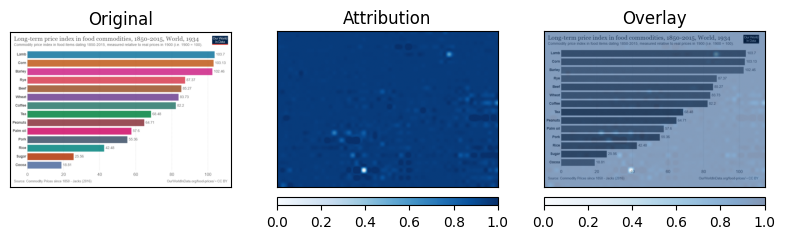

In [34]:
patch_size = processor.image_processor.patch_size
image = records[0]["image"]
pixel_attr = attributions[1].cpu().detach()
image_grid_thw = inputs.image_grid_thw
prepare_for_visualization(image, pixel_attr,
                          image_grid_thw[0],
                          patch_size=patch_size)

In [35]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [36]:
import matplotlib.pyplot as plt


def show_side_by_side(original_image, pixel_values, pixel_attr, image_grid_thw,
                      patch_size=14, cmap="gray"):
    grid_t, grid_h, grid_w = image_grid_thw

    # build coarse map from pixel_values (same as gray version)
    pv_attr = pixel_attr.reshape(grid_t, grid_h, grid_w, -1)[0]
    heat_2d = pv_attr.mean(axis=-1)
    heat_2d = (heat_2d - heat_2d.min()) / (heat_2d.max() - heat_2d.min() + 1e-8)

    # build coarse map from pixel_values (same as gray version)
    pv = pixel_values.reshape(grid_t, grid_h, grid_w, -1)[0]
    pv = pv.mean(axis=-1)
    pv = (pv - pv.min()) / (pv.max() - pv.min() + 1e-8)

    # size of the resized image inside the processor
    resized_H = grid_h * patch_size
    resized_W = grid_w * patch_size

    # resize original image to match
    img_resized = original_image.resize((resized_W, resized_H))
    

    _, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(img_resized)
    axs[0].set_title("Original (resized)")
    axs[0].axis("off")

    axs[1].imshow(pv, cmap=cmap)
    axs[1].set_title("pixel_values (mean per patch)")
    axs[1].axis("off")

    axs[2].imshow(heat_2d, cmap=cmap)
    axs[2].set_title("pixel_values attributions (mean per patch)")
    axs[2].axis("off")

    plt.tight_layout()
    plt.show()


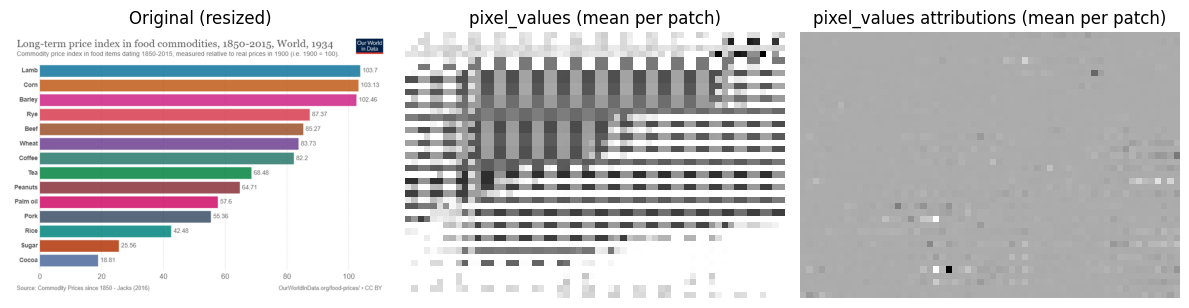

In [37]:
patch_size = processor.image_processor.patch_size
show_side_by_side(image, pixel_values.cpu().detach(), pixel_attr, image_grid_thw[0],
                      patch_size=patch_size,)

In [38]:
import matplotlib.pyplot as plt
from captum.attr import visualization


def show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw, cmap="gray"):
    grid_t, grid_h, grid_w = image_grid_thw

    # build coarse map from pixel_values (same as gray version)
    pv_attr = pixel_attr.reshape(grid_t, grid_h, grid_w, -1)[0]
    # heat_2d = pv_attr.mean(axis=-1)
    # heat_2d = (heat_2d - heat_2d.min()) / (heat_2d.max() - heat_2d.min() + 1e-8)

    # build coarse map from pixel_values (same as gray version)
    pv = pixel_values.reshape(grid_t, grid_h, grid_w, -1)[0]
    pv = pv.mean(axis=-1).unsqueeze(2)
    # pv = (pv - pv.min()) / (pv.max() - pv.min() + 1e-8)

    # size of the resized image inside the processor
    # resized_H = grid_h * patch_size
    # resized_W = grid_w * patch_size
    print(pv.shape, pv_attr.shape)


# --- 5. Use Captum's visualize_image_attr_multiple ---
    visualization.visualize_image_attr_multiple(
        pv_attr.cpu().detach().numpy(),
        pv.cpu().detach().numpy(),
        methods=["original_image", "heat_map", "blended_heat_map"],
        signs=["all", "all", "all"],
        show_colorbar=True,
        titles=["Original", "Attribution", "Overlay"],
    )


torch.Size([42, 60, 1]) torch.Size([42, 60, 1176])


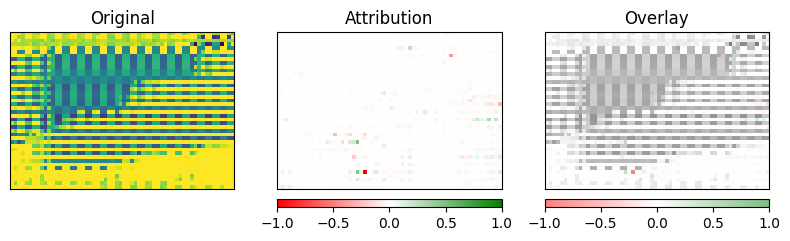

In [39]:
show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw[0], cmap="gray")

#### Token visualization

In [40]:
attributions[0].shape

torch.Size([1, 678, 2048])

In [41]:
img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()


In [42]:
attributions[0][token_mask].shape

torch.Size([48, 2048])

In [43]:
# text_attributions_norm = attributions[0].sum(dim=2).squeeze(0).norm()
# text_attr = attributions[0].sum(dim=2).squeeze(0) / text_attributions_norm

text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm

In [44]:
records[0]

{'id': 0,
 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=850x600>,
 'question': 'How many food item is shown in the bar graph?',
 'gold_answers': ['14'],
 'prediction': '14',
 'correct': True,
 'first_tokens': tensor([16])}

In [ ]:
target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]
pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [49]:
prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
prompt_text

'<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|vision_end|>Answer concisely with a single number, word or short phrase.\nQuestion: How many food item is shown in the bar graph?<|im_end|>\n<|im_start|>assistant\n'

In [50]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            target_token.item(),
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
visualization.visualize_text(vis_data_records)

### LXT

In [51]:
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm

from lxt.efficient.patches import patch_method, patch_attention, patch_cp_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, cp_gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from functools import partial
from torch.nn import Dropout, LayerNorm

# from lxt.efficient.models import get_default_map
from lxt.efficient.patches import patch_method, patch_attention, layer_norm_forward
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit


def configure_lxt(model, use_zennit=False):

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        # monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    model.train()  # Switch to train mode to enable  gradient flow
    model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp



In [52]:
use_zennit = False
attnLRP = {
        Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
        Qwen2RMSNorm: partial(patch_method, rms_norm_forward), 
        Dropout: partial(patch_method, dropout_forward),
        modeling_qwen2_5_vl: patch_attention,
    }

monkey_patch(modeling_qwen2_5_vl, patch_map=attnLRP, verbose=True)
if use_zennit:
    monkey_patch_zennit(verbose=True)

Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl


In [53]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()
model_wrapper = QwenVL_Wrapper(model, processor)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [54]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [55]:
zennit_comp = configure_lxt(model_wrapper.hf_model, use_zennit=False)

In [60]:
torch.cuda.empty_cache()


#### Attribution

In [69]:
def get_relevance(model_wrapper, inputs, zennit_comp=None, gen_ids=None,
                  full_relevance=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    # if gen_ids is not None:
    #     ctx_len = input_ids.size(1)
    #     gen_ids_new = gen_ids[:, ctx_len:]
    #     L_gen = gen_ids_new.size(1)
    #     input_ids = torch.cat([input_ids, gen_ids_new], dim=1)
    #     attention_mask = torch.ones_like(input_ids, device=model.device)

    # Text embeddings
    text_embeds = model_wrapper.text_embeddings_layer(input_ids).clone().detach()
    # if full_relevance:
    text_embeds.requires_grad_(True) # .to(model.device)
    pixel_values.requires_grad_(True)

    log_logits = model_wrapper(text_embeds, pixel_values,
                            attention_mask, input_ids, image_grid_thw,
                            return_probs=True)
    max_logits, _ = torch.max(log_logits, dim=-1)
    max_logits.backward()

    # if not full_relevance:
    #     inputs_embeds = inputs_embeds.detach().requires_grad_(True)

    # # inference and get the maximum logit at the last position (we can also explain other tokens)
    # outputs = model(
    #                 #input_ids=input_ids,
    #                 inputs_embeds=inputs_embeds,
    #                 attention_mask=attention_mask,
    #                 #image_grid_thw=image_grid_thw,
    #                 #pixel_values=pixel_values,
    #                 #position_ids=position_ids,
    #                 use_cache=False
    #                 )
    
    # output_logits = outputs["logits"]

    # if gen_ids is not None:
    #     L_gen = gen_ids_new.size(1)
        
    #     # positions whose logits predict each generated token
    #     indices = torch.arange(
    #         ctx_len - 1,
    #         ctx_len - 1 + L_gen,
    #         device=model.device
    #     )  # shape [L_gen]

    #     selected_logits = output_logits[0, indices, gen_ids_new[0]]   # [L_gen]
    #     selected_logits.backward(torch.ones_like(selected_logits))
    # else:
    #     max_logits, _ = torch.max(output_logits[0, -1, :], dim=-1)
    #     max_logits.backward()

    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    # if full_relevance:
    relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
    #relevance_img_norm = relevance_img / relevance_img.abs().max()

    relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
    #relevance_text_norm = relevance_text / relevance_text.abs().max()
    return relevance_img, relevance_text
    # else:
    #     relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0]
    #     return relevance, relevance

       

In [70]:
full_relevance = True
if full_relevance:
    relevance_img, \
        relevance_text = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    gen_ids=None)
else:
    relevance_img = None
    relevance_text, _ = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    gen_ids=None)

In [73]:
# Token attribution
input_ids = inputs.input_ids

img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                            skip_special_tokens=False,
                            clean_up_tokenization_spaces=False)[0]

In [74]:
# text_attributions_norm = relevance_text[token_mask].sum(dim=-1).norm()
text_attr = relevance_text[token_mask] / relevance_text[token_mask].abs().max()

In [77]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                    text_attr,
                    target_token.item(),
                    pred_class,
                    true_class,
                    true_class,
                    text_attr.sum(),       
                    prompt_text.split(),
                    0.0)]
visualization.visualize_text(vis_data_records)

In [78]:
torch.cuda.empty_cache()

In [83]:
from viz_utils import prepare_for_visualization, show_side_by_side, show_pixel_attribution_captum

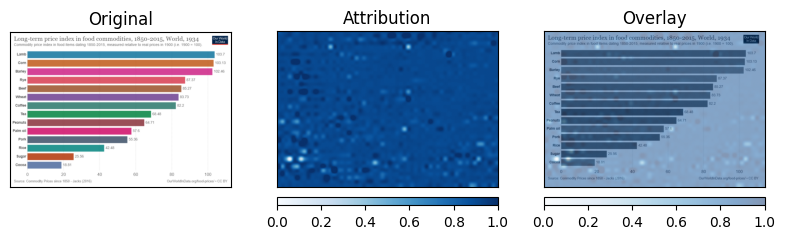

In [86]:
patch_size = processor.image_processor.patch_size
image = records[0]["image"]
pixel_attr = relevance_img.cpu().detach()
image_grid_thw = inputs.image_grid_thw
prepare_for_visualization(image, pixel_attr,
                          image_grid_thw[0],
                          patch_size=patch_size)

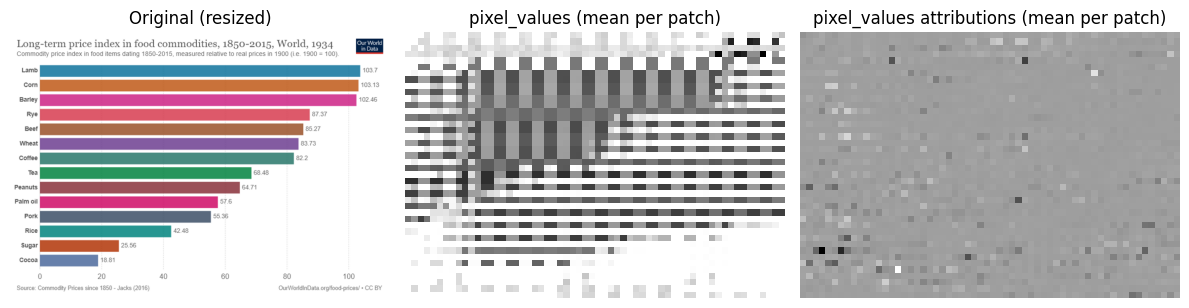

In [88]:
patch_size = processor.image_processor.patch_size
show_side_by_side(image, pixel_values.cpu().detach(), pixel_attr, image_grid_thw[0],
                      patch_size=patch_size,)

torch.Size([42, 60, 1]) torch.Size([42, 60, 1176])


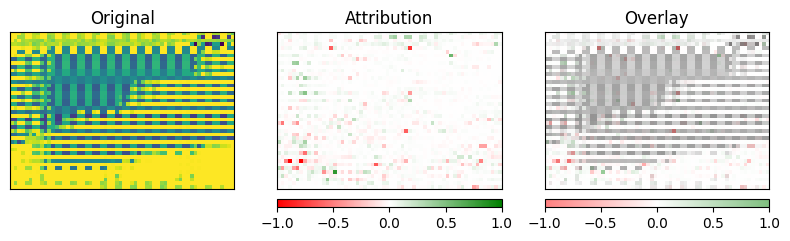

In [90]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)
show_pixel_attribution_captum(pixel_values, pixel_attr,
                                  image_grid_thw[0], cmap=default_cmap)

#### Faithfulness

In [93]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [94]:
pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = relevance_img.cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [95]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values.unsqueeze(0),
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution.unsqueeze(0),
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [97]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.63931884765625,
 'negative_auc': -0.25439453124999994,
 'gap_auc': 0.38492431640624997}

In [98]:
relevance_text.shape

torch.Size([1, 678])

In [99]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = relevance_text.cpu().detach()
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [100]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [102]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -7.162341308593749,
 'negative_auc': -8.68472900390625,
 'gap_auc': -1.5223876953125}

#### Draft code

In [79]:
from einops import rearrange

attributions_img = rearrange(relevance_img[0], 'c h w -> h w c')
attributions_img = attributions_img.detach().cpu().numpy()

pixel_values = inputs.pixel_values


original_im_mat = rearrange(pixel_values[0], 'c h w -> h w c')
original_im_mat = original_im_mat.detach().cpu().numpy()

EinopsError:  Error while processing rearrange-reduction pattern "c h w -> h w c".
 Input tensor shape: torch.Size([1176]). Additional info: {}.
 Wrong shape: expected 3 dims. Received 1-dim tensor.

In [ ]:
# image_grid_thw: (B, 3) tensor from the processor

image_grid_thw = inputs["image_grid_thw"]

img_idx = 0
grid_t, grid_h, grid_w = image_grid_thw[img_idx].tolist()  # e.g. [1, H_patches, W_patches]

# relevance: (N,) = (grid_t * grid_h * grid_w,)
relevance_patches = relevance_img.view(grid_t, grid_h, grid_w)

relevance_map = relevance_patches[0]      # (grid_h, grid_w)
patch_size = processor.image_processor.patch_size

resized_height = grid_h * patch_size
resized_width  = grid_w * patch_size

import torch.nn.functional as F

# (H_patches, W_patches) -> (1,1,H_patches,W_patches)
relevance_map_2d = relevance_map.unsqueeze(0).unsqueeze(0)

# Upsample to resized image size
heatmap_resized = F.interpolate(
    relevance_map_2d,
    size=(resized_height, resized_width),
    mode="bilinear",
    align_corners=False,
)  # shape: (1,1,resized_height,resized_width)

heatmap_resized = heatmap_resized.squeeze(0).squeeze(0)  # (resized_height, resized_width)



In [56]:
torch.cuda.empty_cache()

In [ ]:
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def reshape_visual_relevance(model, processor, image_size):

    patch_size = processor.image_processor.patch_size
    spatial_merge_size = model.config.vision_config.spatial_merge_size

    height_new, width_new = smart_resize(
        width=image_size[0],
        height=image_size[1],
        factor=patch_size * processor.image_processor.merge_size,
        min_pixels=processor.image_processor.size["shortest_edge"],
        max_pixels=processor.image_processor.size["longest_edge"],
    )


    n_patches_x = width_new // patch_size // spatial_merge_size
    n_patches_y = height_new // patch_size // spatial_merge_size
    return (n_patches_x, n_patches_y)


def visualize_image_relevance(image, img_relevance, figsize=(8,8), save_path=None):


    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    similarity_map_image = Image.fromarray((img_relevance.cpu().numpy() * 255).astype("uint8")).resize(
            image.size, Image.Resampling.BICUBIC
    )
    # similarity_map_image = Image.fromarray(img_relevance.cpu().numpy()).resize(
    #         image.size, Image.Resampling.BICUBIC
    # )
    
    show_colorbar = False
    # Create the figure
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            similarity_map_image,
            cmap=sns.color_palette("bwr", as_cmap=True),
            alpha=0.5,
        )

        if show_colorbar:
            fig.colorbar(im)
        ax.set_axis_off()
        fig.tight_layout()

        # ---- SAVE FIGURE ----
        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_image_relevance_(image, img_relevance, figsize=(8, 8), save_path=None):
    # Convert the image to an array
    img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

    # img_relevance: torch.Tensor of shape (H_patches, W_patches), values in [-1, 1]
    rel = img_relevance.cpu().numpy().astype("float32")  # (Hp, Wp)
    similarity_map_image = Image.fromarray(rel, mode="F").resize(
        image.size, Image.Resampling.BICUBIC
    )
    print(similarity_map_image.size)

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=figsize)

        ax.imshow(img_array)
        im = ax.imshow(
            np.array(similarity_map_image),
            cmap="bwr",
            alpha=0.5,
            vmin=-1,
            vmax=1,
        )

        ax.set_axis_off()
        fig.tight_layout()

        if save_path is None:
            save_path = "relevance_img_overlay.png"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)


def visualize_text_relevance(text, token_relevance, figsize=(8,8), save_path=None):

    # "Importance": abs by default (signed scores → magnitude)
    idx_max = int(torch.argmax(token_relevance))

    # Keep it readable: show top-k (optional)
    k = min(30, len(text))
    top_idx = torch.topk(token_relevance, k).indices.tolist()[::-1]  # highest → lowest
    top_text = [text[i] for i in top_idx]
    top_imp    = token_relevance[top_idx].numpy()

    # Colors: grey for all, one highlighted
    colors = ['lightgray'] * k
    colors[top_idx.index(idx_max)] = 'tab:red'  # color only the most important

    plt.figure(figsize=figsize)
    y = np.arange(k)
    plt.barh(y, top_imp, color=colors)
    plt.yticks(y, top_text)
    plt.gca().invert_yaxis()
    plt.xlabel('Token importance (|relevance|)')
    plt.title('Top-k token attributions (max highlighted)')
    plt.tight_layout()
    # ---- SAVE FIGURE ----
    if save_path is None:
        save_path = "relevance_prompt_overlay.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")



In [58]:
relevance_text_norm = relevance_text / relevance_text.abs().max()
if full_relevance:
    relevance_img_norm = relevance_img / relevance_img.abs().max()
else:
    relevance_img_norm = None

In [42]:
inputs["input_ids"].shape

torch.Size([1, 3606])

In [43]:
relevance_text_norm.shape

torch.Size([3606])

In [64]:
from einops import rearrange

def prepare_relevance_for_visualization(input_ids, image, processor,
                                        image_grid_thw,
                                        relevance_text_norm,
                                        relevance_img_norm=None):
    img_mask = (input_ids == processor.image_token_id)
    token_mask = (input_ids != processor.image_token_id)
    img_mask = img_mask.cpu()
    token_mask = token_mask.cpu()

    idx = 0
    image_size = image.size
    n_patches = reshape_visual_relevance(model, processor, image_size)

    if relevance_img_norm is None:
        patch_relevance = rearrange(
                            relevance_text_norm[img_mask[idx]],  # (n_patches_x * n_patches_y, dim)
                            "(h w) -> w h",
                            w=n_patches[0],
                            h=n_patches[1],
                        )  # (n_patches_x, n_patches_y, dim)
        
    else:
        assert(relevance_text_norm[img_mask[idx]].sum().cpu().numpy() == 0)


        # image_grid_thw: (B, 3) tensor from the processor
        grid_t, grid_h, grid_w = image_grid_thw[idx].tolist()  # e.g. [1, H_patches, W_patches]

        # relevance: (N,) = (grid_t * grid_h * grid_w,)
        patch_relevance = relevance_img_norm.view(grid_t, grid_h, grid_w)

    ids = input_ids[idx][token_mask[idx]]
    token_relevance = relevance_text_norm[token_mask[idx]]

    prompt_text = processor.batch_decode(
        ids, skip_special_tokens=False, clean_up_tokenization_spaces=True
    )

    return token_relevance, patch_relevance, prompt_text


In [65]:
relevance_text_norm.shape

torch.Size([3606])

In [66]:
input_ids.shape

torch.Size([1, 3606])

In [67]:
input_ids = inputs["input_ids"]
image_grid_thw = inputs["image_grid_thw"]

use_target = False
if use_target:
    ctx_len = input_ids.size(1)
    gen_ids_new = gen_ids[:, ctx_len:]
    input_ids = torch.cat([input_ids, gen_ids_new], dim=1)

token_relevance, \
patch_relevance, \
prompt_text = prepare_relevance_for_visualization(input_ids,
                                                image,
                                                processor,
                                                image_grid_thw,
                                                relevance_text_norm,
                                                relevance_img_norm=relevance_img_norm)

In [75]:
full_relevance

True

In [76]:
patch_relevance.sum()

tensor(1.0861)

In [73]:
visualize_image_relevance(image, patch_relevance[0])


In [49]:
visualize_text_relevance(prompt_text, token_relevance)

In [17]:
image.size

(2048, 1365)

In [52]:
from IPython.display import display, HTML

# --- Assume you have your 'tokens' list and 'relevance' tensor ---

def colorize_tokens(tokens, scores):
    """Generates an HTML string with colored token backgrounds."""
    html_string = ""
    # Normalize scores for color mapping
    scores = torch.from_numpy(np.array(scores))
    scores = scores / scores.abs().max()

    for token, score in zip(tokens, scores):
        # Use blue for positive relevance, red for negative
        if score > 0:
            # Alpha (opacity) is proportional to the score
            color = f"rgba(0, 0, 255, {score:.2f})"
        else:
            # Use the absolute value for opacity
            color = f"rgba(255, 0, 0, {abs(score):.2f})"

        # Add a space after each token for readability
        html_string += f'<span style="background-color: {color};">{token}</span> '

    return html_string

# Generate the HTML
html_output = colorize_tokens(output_text, text_relevance_for_heatmap)

# Display it in the notebook
print("Token Relevance:")
display(HTML(html_output))

Token Relevance:


## Llava 1-5

In [1]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration
from transformers import BitsAndBytesConfig

model_id = "llava-hf/llava-1.5-7b-hf"

def load_llava_model(model_id):

    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16, # use bfloat16 to prevent overflow in gradients
)
    
    model = LlavaForConditionalGeneration.from_pretrained(
        model_id, 
        dtype=torch.bfloat16, 
        low_cpu_mem_usage=True,
        quantization_config=bnb_config,
    ).to(0)

    processor = AutoProcessor.from_pretrained(model_id)
    return model, processor

In [2]:
model_id = "llava-hf/llava-1.5-7b-hf"
model, processor = load_llava_model(model_id)
model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


LlavaForConditionalGeneration(
  (model): LlavaModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affi

In [4]:
model.vision_tower

CLIPVisionModel(
  (vision_model): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(577, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear4bit(in_features=1024, out_

In [5]:
model.language_model

LlamaModel(
  (embed_tokens): Embedding(32064, 4096)
  (layers): ModuleList(
    (0-31): 32 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
        (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
        (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((4096,), eps=1e-05)
  (rotary_emb): LlamaRotaryEmbedding()
)

In [5]:
torch.cuda.empty_cache()

In [4]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceM4/ChartQA", split="test[:10]")

In [6]:
from PIL import Image


def get_inputs(image: Image.Image, question: str):
    conversation = [
        {

        "role": "user",
        "content": [
            {"type": "text", "text": (
                        "Answer concisely with a single number, word or short phrase.\n"
                        f"Question: {question}"
                    ),
            },
            {"type": "image"},
            ],
        },
    ]
    # Preparation for inference
    prompt = processor.apply_chat_template(
        conversation, add_generation_prompt=True
    )
    # image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=prompt,
        images=image,
        # padding=True,
        return_tensors="pt",
    )

    inputs.to(model.device)
    return inputs

def predict_answer(image: Image.Image, question: str, dtype=torch.bfloat16) -> dict:
    

    #  # ---- Convert everything that can be bf16 into bf16 ----
    # if dtype is not None:
    #     for k in inputs:
    #         if torch.is_floating_point(inputs[k]) and inputs[k].dtype != dtype:
    #             inputs[k] = inputs[k].to(dtype=dtype)

    inputs = get_inputs(image, question)


    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=32)

    # strip prompt
    prompt_len = inputs["input_ids"].shape[1]
    answer_ids = generated_ids[:, prompt_len:]
    out = processor.batch_decode(
        answer_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]
    answer_text = out.strip()
    # answer_token_ids = answer_ids[0].tolist()
    # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
    return {
        "text": answer_text,
        "first_tokens": answer_ids[:, 0].cpu(),
        # "tokens": answer_tokens
    }



In [7]:
import gc
verbose = True
records = []  # this will hold all the info you want to reuse

for idx, sample in enumerate(dataset):
    img = sample["image"]       # PIL image
    q = sample["query"]
    golds = [a.lower().strip() for a in sample["label"]]

    pred_dict = predict_answer(img, q)
    pred_text =  pred_dict["text"]
    pred_lower = pred_text.lower()
    pred_first_tokens = pred_dict["first_tokens"]
    # pred_tokens = pred_dict["tokens"]

    correct = any(g in pred_lower for g in golds)

    if verbose:

        print(f"[{idx}] Q: {q}")
        print(f"    gold: {golds}")
        print(f"    pred: {pred_text}")
        print(f"    correct: {correct}\n")

    # Store everything you’ll need later
    records.append(
        {
            "id": idx,
            "image": img,              # keep the PIL image in memory
            "question": q,
            "gold_answers": golds,
            "prediction": pred_text,
            "correct": correct,
            "first_tokens": pred_first_tokens,
            # "tokens": pred_tokens,
        }    
    )
    gc.collect()
    torch.cuda.empty_cache()


[0] Q: How many food item is shown in the bar graph?
    gold: ['14']
    pred: 10
    correct: False

[1] Q: What is the difference in value between Lamb and Corn?
    gold: ['0.57']
    pred: 100
    correct: False

[2] Q: How many bars are shown in the chart?
    gold: ['3']
    pred: 2
    correct: False

[3] Q: Is the sum value of Madagascar more then Fiji?
    gold: ['no']
    pred: No
    correct: True

[4] Q: What's the value of the lowest bar?
    gold: ['23']
    pred: 23
    correct: True

[5] Q: What is the difference between the highest and the lowest green bar??
    gold: ['6']
    pred: 20
    correct: False

[6] Q: What percent who think of President Donald Trump as Dangerous?
    gold: ['62']
    pred: 52
    correct: False

[7] Q: Is the sum of the percents of Charismatic and Well-qualified to be president more than A strong leader ?
    gold: ['yes']
    pred: Yes
    correct: True

[8] Q: What was the 4th most popular emotion?
    gold: ['inspired']
    pred: Anger


In [9]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class Llava_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                return_probs=False
                ):
        

        # Vision embeddings
        image_features = self.hf_model.model.get_image_features(
                pixel_values=pixel_values,
                vision_feature_layer=None,
                vision_feature_select_strategy=None,
                image_sizes=None,
            )
        image_features = torch.cat(image_features, dim=0).to(text_embeds.device, text_embeds.dtype)
        special_image_mask = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_features
        )
        inputs_embeds = text_embeds.masked_scatter(special_image_mask, image_features)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        # Compute the log_softmax
        if return_probs:
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
        # del outputs
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32):
        with torch.no_grad():
            generated_ids = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           max_new_tokens=max_new_tokens)

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        return answer_ids[:, 0].cpu(), answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "Llava_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


### Captum

In [10]:
model_wrapper = Llava_Wrapper(model, processor)


In [11]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [12]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    TokenReferenceBase,
    visualization
)

import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import torch

In [13]:
from einops import rearrange

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

def get_attributions_plot(model_wrapper, attr_hf,
                          inputs, target_token,
                          true_class,
                          pred_token=None,
                          pred_class=None,
                          use_baselines=False,
                          plot=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values

    text_embeds = model_wrapper.text_embeddings_layer(input_ids)

    captum_forward = (text_embeds.requires_grad_(), pixel_values.requires_grad_())
    captum_add_forward = (attention_mask, input_ids)

    baselines = None
    if use_baselines:
        # Baselines
        token_reference = TokenReferenceBase(reference_token_idx=model_wrapper.processor.tokenizer.pad_token_id)
        # generate reference for each sample
        reference_ids = token_reference.generate_reference(
                                input_ids.shape[-1],
                                device=model_wrapper.device).unsqueeze(0)
        reference_embeds = model_wrapper.text_embeddings_layer(reference_ids)
        baselines = (reference_embeds, pixel_values * 0.0)

    # Make a forward and predictions
    if pred_token is None:
        pred_token, pred_class = model_wrapper.predict(input_embeds,
                                                    attention_mask,
                                                    input_ids)


    # Get attributions
    if use_baselines:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    baselines=baselines,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    n_steps=10)
    else:
        attributions = attr_hf.attribute(inputs=captum_forward,
                                    target=pred_token,
                                    additional_forward_args=captum_add_forward,
                                    )
    
    if plot:
        # Token attribution
        img_mask = (input_ids == processor.image_token_id)
        token_mask = (input_ids != processor.image_token_id)
        img_mask = img_mask.cpu()
        token_mask = token_mask.cpu()

        prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
        
        text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
        text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm

        vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            true_class,
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
        visualization.visualize_text(vis_data_records)


        # Pixel attributions
        original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
        attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

        visualization.visualize_image_attr_multiple(attributions_img,
                                                    original_im_mat, 
                                                    methods=["original_image", "heat_map", "blended_heat_map"],
                                                    signs=["all", "all", "all"],
                                                    titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                                    cmap=default_cmap,
                                                    show_colorbar=True)


    return attributions



In [14]:
attr_hf = InputXGradient(model_wrapper)
# attr_hf = IntegratedGradients(model_wrapper)


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],-0.44,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


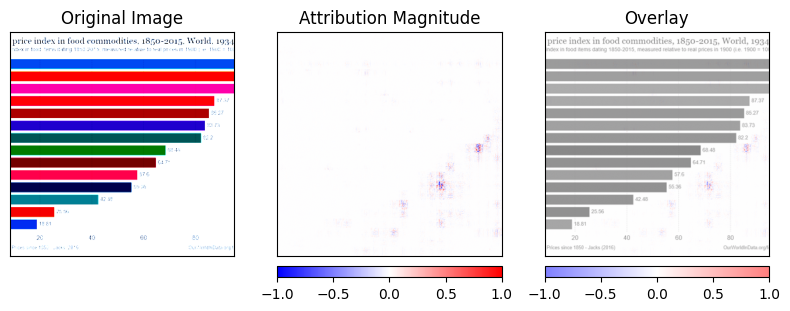

In [16]:
attributions = get_attributions_plot(model_wrapper,
                                     attr_hf=attr_hf,
                                     inputs=inputs,
                                     target_token=target_token,
                                     true_class=true_class,
                                     pred_token=target_token,
                                     pred_class=pred_class,
                                     use_baselines=False,
                                     plot=True
                                     )

In [17]:
torch.cuda.empty_cache()

#### Faithfulness

In [18]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [24]:
from einops import rearrange

pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = rearrange(attributions[1], 'b c h w -> b h w c' ).cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [26]:
pixel_attribution.shape

torch.Size([1, 336, 336])

In [27]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

In [28]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.033935546875,
 'negative_auc': -0.033062744140625,
 'gap_auc': 0.0008728027343749999}

In [29]:
attributions[0].shape

torch.Size([1, 616, 4096])

In [30]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = attributions[0].cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [31]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

In [32]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -1.5392822265625004,
 'negative_auc': -4.85869140625,
 'gap_auc': -3.3194091796875}

#### Text attribution

In [ ]:
default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

In [39]:
attributions[0][token_mask].shape

torch.Size([40, 4096])

In [44]:
prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                                    skip_special_tokens=False,
                                    clean_up_tokenization_spaces=False)[0]
prompt_text

'<s> USER:  \nAnswer concisely with a single number, word or short phrase.\nQuestion: How many food item is shown in the bar graph? ASSISTANT:'

In [47]:
# Visualize text attributions
text_attributions_norm = attributions[0][token_mask].sum(dim=1).norm()
text_attr = attributions[0][token_mask].sum(dim=1) / text_attributions_norm


# Visualize text attributions
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                            text_attr,
                            target_token.item(),
                            pred_class,
                            true_class,
                            target_token.item(),
                            text_attr.sum(),       
                            prompt_text.split(),
                            0.0)]
visualization.visualize_text(vis_data_records)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),29871,-0.71,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),29871,-0.71,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


#### Image attribution

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


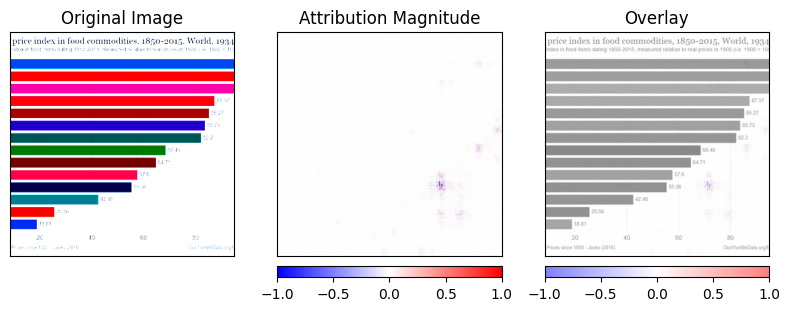

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Attribution Magnitude'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [56]:
# visualize image attributions
original_im_mat = np.transpose(pixel_values[0].cpu().detach().numpy(), (1, 2, 0))
attributions_img = np.transpose(attributions[1].squeeze(0).cpu().detach().numpy(), (1, 2, 0))

visualization.visualize_image_attr_multiple(attributions_img, original_im_mat, 
                                            methods=["original_image", "heat_map", "blended_heat_map"],
                                            signs=["all", "all", "all"],
                                            titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                            cmap=default_cmap,
                                            show_colorbar=True)

In [57]:
attributions_img.shape

(336, 336, 3)

In [22]:
type(model.vision_tower)

transformers.models.clip.modeling_clip.CLIPVisionModel

In [23]:
type(model.language_model)

transformers.models.llama.modeling_llama.LlamaModel

In [26]:
type(model)

transformers.models.llava.modeling_llava.LlavaForConditionalGeneration

### LXT

In [33]:
from functools import partial
from torch.nn import Dropout, LayerNorm

# from lxt.efficient.models import get_default_map
from lxt.efficient.patches import patch_method, patch_attention, layer_norm_forward
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from transformers.models.llama import modeling_llama
from transformers.models.llama.modeling_llama import LlamaMLP, LlamaRMSNorm
from transformers.models.clip import modeling_clip
from transformers.models.llava import modeling_llava

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules



def configure_lxt(model, use_zennit=False):

    zennit_comp = None

    if use_zennit:
        # Define rules for the Conv2d and Linear layers using 'zennit'
        conv_gamma = 100
        lin_gamma = 0.05
        # LayerMapComposite maps specific layer types to specific LRP rule implementations
        zennit_comp = LayerMapComposite([
            (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
            (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
        ])
        
        # monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    model.train()  # Switch to train mode to enable  gradient flow
    model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

    if zennit_comp is not None:
        # Register the composite rules with the model
        zennit_comp.register(model)
    return zennit_comp


In [34]:
use_zennit = False
attnLRP = {
    LlamaMLP: partial(patch_method, gated_mlp_forward),
    LlamaRMSNorm: partial(patch_method, rms_norm_forward),
    Dropout: partial(patch_method, dropout_forward),
    modeling_llama: patch_attention,
    modeling_clip: patch_attention,
    modeling_clip.nn.LayerNorm: partial(patch_method, layer_norm_forward),
}

monkey_patch(modeling_llava, patch_map=attnLRP, verbose=True)
if use_zennit:
    monkey_patch_zennit(verbose=True)

Patched LlamaMLP
Patched LlamaRMSNorm
Patched Dropout
Patched transformers.models.llama.modeling_llama
Patched transformers.models.clip.modeling_clip
Patched LayerNorm


In [35]:
model_id = "llava-hf/llava-1.5-7b-hf"
model, processor = load_llava_model(model_id)
model.eval()
model_wrapper = Llava_Wrapper(model, processor)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [36]:
img = records[0]['image']
question = records[0]['question']
inputs = get_inputs(img, question)

target_token = records[0]["first_tokens"]
pred_text = records[0]['gold_answers'][0]

pred_class = records[0]["prediction"]
true_class = records[0]["gold_answers"]

In [37]:
zennit_comp = configure_lxt(model_wrapper.hf_model, use_zennit=False)

In [38]:
torch.cuda.empty_cache()


#### Attribution

In [39]:
def get_relevance(model_wrapper, inputs, zennit_comp=None,
                  full_relevance=False):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values

    # Text embeddings
    text_embeds = model_wrapper.text_embeddings_layer(input_ids).clone().detach()

    # if full_relevance:
    text_embeds.requires_grad_(True) # .to(model.device)
    pixel_values.requires_grad_(True)

    
    log_logits = model_wrapper(text_embeds, pixel_values,
                            attention_mask, input_ids)
    max_logits, _ = torch.max(log_logits, dim=-1)
    max_logits.backward()


    if zennit_comp is not None:
        # Remove the registered composite to prevent interference in future iterations
        zennit_comp.remove()

    # if full_relevance:
    relevance_img = (pixel_values.grad * pixel_values).float().detach().cpu()
    #relevance_img_norm = relevance_img / relevance_img.abs().max()

    relevance_text = (text_embeds.grad * text_embeds).float().sum(-1).detach().cpu()
    #relevance_text_norm = relevance_text / relevance_text.abs().max()
    return relevance_img, relevance_text
    # else:
    #     relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0]
    #     return relevance, relevance

       

In [41]:
full_relevance = True
if full_relevance:
    relevance_img, \
        relevance_text = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    )
else:
    relevance_img = None
    relevance_text, _ = get_relevance(model_wrapper,
                                    inputs,
                                    zennit_comp=zennit_comp,
                                    full_relevance=full_relevance,
                                    )

In [43]:
# Token attribution
input_ids = inputs.input_ids

img_mask = (input_ids == processor.image_token_id)
token_mask = (input_ids != processor.image_token_id)
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

prompt_text = processor.batch_decode(input_ids[token_mask].unsqueeze(0),
                            skip_special_tokens=False,
                            clean_up_tokenization_spaces=False)[0]

In [46]:
# text_attributions_norm = relevance_text[token_mask].sum(dim=-1).norm()
text_attr = relevance_text[token_mask] / relevance_text[token_mask].abs().max()

In [47]:
from captum.attr import visualization

vis_data_records = [visualization.VisualizationDataRecord(
                    text_attr,
                    target_token.item(),
                    pred_class,
                    true_class,
                    true_class,
                    text_attr.sum(),       
                    prompt_text.split(),
                    0.0)]
visualization.visualize_text(vis_data_records)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],3.79,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
['14'],10 (29871.00),['14'],3.79,"#s USER: Answer concisely with a single number, word or short phrase. Question: How many food item is shown in the bar graph? ASSISTANT:"


In [48]:
torch.cuda.empty_cache()

In [ ]:
from viz_utils import prepare_for_visualization, show_side_by_side, show_pixel_attribution_captum

In [50]:
from einops import rearrange

attributions_img = rearrange(relevance_img[0], 'c h w -> h w c')
attributions_img = attributions_img.detach().cpu().numpy()
pixel_values = inputs.pixel_values


original_im_mat = rearrange(pixel_values[0], 'c h w -> h w c')
original_im_mat = original_im_mat.detach().cpu().numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4856956..2.145897].


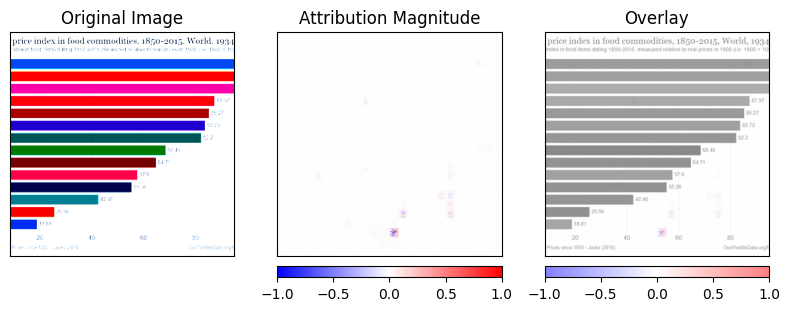

(<Figure size 800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Attribution Magnitude'}>,
        <Axes: title={'center': 'Overlay'}>], dtype=object))

In [51]:
from matplotlib.colors import LinearSegmentedColormap

default_cmap = LinearSegmentedColormap.from_list(
    'red_blue',
    [
        (0.0, '#0000ff'),  # blue   (low values)
        (0.5, '#ffffff'),  # white  (mid)
        (1.0, '#ff0000'),  # red    (high values)
    ],
    N=256,
)

visualization.visualize_image_attr_multiple(attributions_img,
                                            original_im_mat, 
                                            methods=["original_image", "heat_map", "blended_heat_map"],
                                            signs=["all", "all", "all"],
                                            titles=["Original Image", "Attribution Magnitude", "Overlay"],
                                            cmap=default_cmap,
                                            #outlier_perc=0,
                                            show_colorbar=True)

#### Faithfulness

In [54]:
relevance_img.shape

torch.Size([1, 3, 336, 336])

In [52]:
from metrics import eval_image_perturbation_batch, eval_token_perturbation_batch, compute_auc

In [55]:
from einops import rearrange

pixel_values = inputs.pixel_values
target_idx = target_token.to(model_wrapper.device).long()
pixel_attribution = rearrange(relevance_img, 'b c h w -> b h w c' ).cpu().detach().mean(dim=-1)
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
# target_idx_t = torch.Tensor([target_idx], device=model.device).long()
forward_fn_pixel = model_wrapper.get_forward_fn(inputs=inputs, perturbed='pixels')


In [56]:
res_pos = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=True                                    
                                    )

res_neg = eval_image_perturbation_batch(model_wrapper=model_wrapper,
                                    pixel_values=pixel_values,
                                    target_idx=target_idx,
                                    pixel_attribution=pixel_attribution,
                                    perturbation_steps=perturbation_steps,
                                    forward_fn=forward_fn_pixel,
                                    descending=False                                    
                                    )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [57]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -0.039239501953125006,
 'negative_auc': -0.035369873046875,
 'gap_auc': 0.0038696289062500003}

In [58]:
input_ids = inputs.input_ids
attention_mask = inputs.attention_mask
target_idx = target_token.to(model_wrapper.device).long()
token_attribution = relevance_text.cpu().detach()
perturbation_steps = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1]
forward_fn_token = model_wrapper.get_forward_fn(inputs=inputs, perturbed='input_ids')
mask_token_id = processor.tokenizer.pad_token_id
pad_token_id = processor.tokenizer.pad_token_id
token_mask = (input_ids != processor.image_token_id)


In [59]:
res_pos = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=True,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

res_neg = eval_token_perturbation_batch(model_wrapper=model_wrapper,
                                        input_ids=input_ids,
                                        attention_mask=attention_mask,
                                        target_idx=target_idx,
                                        token_attribution=token_attribution,
                                        perturbation_steps=perturbation_steps,
                                        forward_fn=forward_fn_token,
                                        mask_token_id=mask_token_id,
                                        pad_token_id=pad_token_id,
                                        descending=False,
                                        use_sigmoid=False,
                                        text_token_mask=token_mask,
                                        )

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [60]:
compute_auc(res_pos["target_prob_pert"],
            res_neg["target_prob_pert"],
            perturbation_steps)

{'positive_auc': -4.2718750000000005,
 'negative_auc': -0.978533935546875,
 'gap_auc': 3.293341064453125}

## CLIPModel

In [22]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

In [23]:
from PIL import Image
import requests

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = processor(text=["a photo of a cat", "a photo of a dog"], images=image, return_tensors="pt", padding=False)


In [24]:
image.size

(640, 480)

In [26]:
list(inputs.keys())

['pixel_values', 'input_ids', 'attention_mask']

In [27]:
inputs.input_ids.shape

torch.Size([2, 7])

In [28]:
inputs.pixel_values.shape

torch.Size([1, 3, 224, 224])

In [29]:
outputs = model(**inputs)

In [31]:
outputs.logits_per_text.shape

torch.Size([2, 1])

In [32]:
outputs.logits_per_image.shape

torch.Size([1, 2])

In [ ]:
from abc import abstractmethod
from typing import Any, Dict, Literal, Union, Callable, Optional
from torch import nn

class CLIP_Wrapper(nn.Module):
    def __init__(self, model, processor) -> None:
        super().__init__()
        self.hf_model = model
        self.processor = processor

    @property
    @abstractmethod
    def text_embeddings_layer(self) -> nn.Module:
        """
        Return the nn.Module that corresponds to the text embedding layer
        of the underlying HF model.

        Must be implemented in subclasses, for example:
            return self.hf_model.get_input_embeddings()
        or
            return self.hf_model.vilt.text_embeddings
        depending on the architecture.
        """
        #raise NotImplementedError
        return self.hf_model.get_input_embeddings()

    def get_forward_fn(self, inputs,
                   perturbed: Literal["pixels", "input_ids"] = "pixels",
                   ):
        device = self.device
        inputs = inputs.to(device)

        if perturbed == "pixels":
            input_ids      = inputs.get("input_ids", None)
            attention_mask = inputs.get("attention_mask", None)

            text_embeds = self.text_embeddings_layer(input_ids)
            if text_embeds is None:
                raise ValueError("Need input_ids to build text embeddings")
            
            def forward_pixels(pixel_values):
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_pixels
        
        elif perturbed == "input_ids":
            pixel_values   = inputs.get("pixel_values", None)

            if pixel_values is None:
                raise ValueError("Need pixel_values to build text embeddings")
            
            def forward_input_ids(input_ids, attention_mask):
                text_embeds = self.text_embeddings_layer(input_ids)
                log_logits = self.forward(text_embeds,
                                        pixel_values,
                                        attention_mask,
                                        input_ids,
                                        return_probs=False
                                        )
                return log_logits
            return forward_input_ids
        
        else:
            raise ValueError("Perturbed must be either 'pixels' or 'input_ids'")

    def forward(self, text_embeds,
                pixel_values,
                attention_mask,
                input_ids,
                return_probs=False
                ):
        

        # Vision embeddings
        image_features = self.hf_model.model.get_image_features(
                pixel_values=pixel_values,
                vision_feature_layer=None,
                vision_feature_select_strategy=None,
                image_sizes=None,
            )
        image_features = torch.cat(image_features, dim=0).to(text_embeds.device, text_embeds.dtype)
        special_image_mask = self.hf_model.model.get_placeholder_mask(
            input_ids, inputs_embeds=text_embeds, image_features=image_features
        )
        inputs_embeds = text_embeds.masked_scatter(special_image_mask, image_features)

        # inference and get the maximum logit at the last position (we can also explain other tokens)
        outputs = self.hf_model(
                        #input_ids=input_ids,
                        inputs_embeds=inputs_embeds,
                        attention_mask=attention_mask,
                        #image_grid_thw=image_grid_thw,
                        #pixel_values=pixel_values,
                        use_cache=False
                        )
        
        logits = outputs["logits"] # (B, prompt_len, vocab_size)
        new_token_logits = logits[:, -1]  # (B, vocab_size)

        # Compute the log_softmax
        if return_probs:
            log_probs = torch.nn.functional.log_softmax(new_token_logits, dim=-1) # (B, vocab_size)
        # del outputs
            return log_probs
        else:
            return new_token_logits
    
    def predict(self, inputs_embeds,
                attention_mask,
                input_ids,
                max_new_tokens=32):
        with torch.no_grad():
            generated_ids = model.generate(inputs_embeds=inputs_embeds,
                                           attention_mask=attention_mask,
                                           max_new_tokens=max_new_tokens)

        # strip prompt
        prompt_len = input_ids.shape[1]
        answer_ids = generated_ids[:, prompt_len:]
        out = processor.batch_decode(
            answer_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0]
        answer_text = out.strip()
        # answer_token_ids = answer_ids[0].tolist()
        # answer_tokens = processor.tokenizer.convert_ids_to_tokens(answer_token_ids)
        return answer_ids[:, 0].cpu(), answer_text
    
    # --------- device helpers ---------
    @property
    def device(self) -> torch.device:
        """
        Return the device of the underlying HF model.

        This assumes the model has parameters; if not, you may need to adapt.
        """
        return next(self.hf_model.parameters()).device

    def to_device(self, device: Union[str, torch.device]) -> "Llava_Wrapper":
        """
        Move the wrapper (and thus the HF model) to the given device.

        Returns self to allow chaining:
            wrapper.to_device("cuda")
        """
        device = torch.device(device)
        # nn.Module.to(...) will move all registered submodules, including hf_model
        super().to(device)
        return self
    


## ColQwen

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from datasets import load_dataset
from qwen_vl_utils import process_vision_info
import Levenshtein
import string
import re

# -----------------------------------------------------------------------------
# 1. METRIC: ANLS (Average Normalized Levenshtein Similarity)
# -----------------------------------------------------------------------------
def get_anls(prediction, ground_truth):
    """
    Calculates ANLS between a prediction and a single ground truth string.
    Formula: 1 - (distance / max_length)
    Threshold: If score < 0.5, return 0.0
    """
    prediction = prediction.lower().strip()
    ground_truth = ground_truth.lower().strip()
    
    if not prediction and not ground_truth:
        return 1.0
    if not prediction or not ground_truth:
        return 0.0
        
    dist = Levenshtein.distance(prediction, ground_truth)
    max_len = max(len(prediction), len(ground_truth))
    
    score = 1.0 - (dist / max_len)
    
    # ANLS threshold: predictions with < 50% similarity get 0 points
    if score < 0.5:
        return 0.0
    return score

def compute_max_anls(prediction, ground_truth_list):
    """
    DocVQA provides multiple acceptable answers (e.g. ['2023', '2023.']).
    We take the BEST score among all ground truths.
    """
    scores = [get_anls(prediction, gt) for gt in ground_truth_list]
    return max(scores) if scores else 0.0

# -----------------------------------------------------------------------------
# 2. MODEL SETUP
# -----------------------------------------------------------------------------
# Using Qwen2-VL-2B for efficiency. 
# DocVQA images are often tall/wide documents, so we allow higher resolution.
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_ID} on {DEVICE}...")

# min_pixels/max_pixels are crucial for Documents to ensure text is readable
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, 
    torch_dtype="auto", 
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=1280*28*28)

# -----------------------------------------------------------------------------
# 3. DATASET LOADING
# -----------------------------------------------------------------------------
# "lmms-lab/DocVQA" is a clean version of the dataset often used for VL evaluations
print("Loading DocVQA dataset (validation subset)...")
dataset = load_dataset("lmms-lab/DocVQA", split="validation[:10]")

# -----------------------------------------------------------------------------
# 4. EVALUATION LOOP
# -----------------------------------------------------------------------------
anls_scores = []

print(f"\nStarting evaluation on {len(dataset)} document samples...\n")

for i, sample in enumerate(dataset):
    image = sample["image"]
    question = sample["question"]
    
    # DocVQA answers are typically a list of strings
    ground_truths = sample["answers"]

    # Prepare prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"{question}"} 
            ],
        }
    ]

    # Preprocess
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    
    inputs = processor(
        text=[text_input],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(DEVICE)

    # Generate
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=50) # Docs might need longer answers
        
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    prediction = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    # Compute Score
    score = compute_max_anls(prediction, ground_truths)
    anls_scores.append(score)

    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------
    print(f"Sample {i+1}:")
    print(f"  Question: {question}")
    print(f"  Prediction: '{prediction}'")
    print(f"  Ground Truths: {ground_truths}")
    print(f"  ANLS Score: {score:.4f}")
    print("-" * 40)

# -----------------------------------------------------------------------------
# 5. FINAL RESULTS
# -----------------------------------------------------------------------------
avg_anls = sum(anls_scores) / len(anls_scores)
print(f"\nEvaluation Complete.")
print(f"Average ANLS: {avg_anls:.4f} (0.0 to 1.0)")

In [1]:
import torch
from PIL import Image
from transformers.utils.import_utils import is_flash_attn_2_available

from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor

In [ ]:
model = ColQwen2_5.from_pretrained(
        "vidore/colqwen2.5-v0.2",
        torch_dtype=torch.bfloat16,
        device_map="cuda:0",  # or "mps" if on Apple Silicon
        attn_implementation=None, #"flash_attention_2" if is_flash_attn_2_available() else None,
    ).eval()
processor = ColQwen2_5_Processor.from_pretrained("vidore/colqwen2.5-v0.2")



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
import mteb

tasks = mteb.get_tasks(tasks=["VidoreArxivQARetrieval"], task_types=["DocumentUnderstanding"], modalities=["text", "image"], languages=['eng'])

In [4]:
task = tasks[0]
task.load_data()             # ensure data is present

corpus = task.corpus["test"]
queries = task.queries["test"]   # dict[qid] -> text

In [35]:
images = [corpus[i]["image"] for i in range (1)]
quest = [queries[i]["text"] for i in range (1)]

In [36]:
quest[0]

'Based on the graph, what is the impact of correcting for fspec not equal to 1 on the surface density trend?'

In [37]:
# Process the inputs
batch_images = processor.process_images(images).to(model.device)
batch_queries = processor.process_queries(quest).to(model.device)


In [44]:
# Forward pass
with torch.no_grad():
    image_embeddings = model(**batch_images)
    query_embeddings = model(**batch_queries)

scores = processor.score_multi_vector(query_embeddings, image_embeddings)

/home/jky/.conda/envs/jky-vdoc/lib/python3.11/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [45]:
scores

tensor([[27.7500]])

In [77]:
print(model.visual)

Qwen2_5_VisionTransformerPretrainedModel(
  (patch_embed): Qwen2_5_VisionPatchEmbed(
    (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
  )
  (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x Qwen2_5_VLVisionBlock(
      (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
      (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
      (attn): Qwen2_5_VLVisionAttention(
        (qkv): Linear(in_features=1280, out_features=3840, bias=True)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): Qwen2_5_VLMLP(
        (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
        (act_fn): SiLU()
      )
    )
  )
  (merger): Qwen2_5_VLPatchMerger(
    (ln_q): Qwen2RMSNorm((1280,), eps=1e-06)
    (mlp): Sequential(
      (0): Linear(in_fea

In [ ]:
text_tokens = []
text_relevance_scores = []
image_patch_relevance_scores = []

input_ids_list = inputs['input_ids'][0].tolist()
relevance_list = relevance.tolist()
image_token_id = processor.tokenizer.image_token_id

patch_index = 0
for i, token_id in enumerate(input_ids_list):
    current_relevance = relevance_list[i]
    
    if token_id == image_token_id:
        # This is an image patch
        image_patch_relevance_scores.append((patch_index, current_relevance))
        
        # For visualization, you might want a placeholder
        text_tokens.append(f"[PATCH_{patch_index}]")
        text_relevance_scores.append(current_relevance)
        patch_index += 1
        
    else:
        # This is a text token
        token_str = processor.tokenizer.decode([token_id])
        text_tokens.append(token_str)
        text_relevance_scores.append(current_relevance)

# 1. For text attribution:
# You can now plot the text relevance just like in the example
print("Text Attributions:")
for token, score in zip(text_tokens, text_relevance_scores):
    print(f"{token}: {score:.4f}")

# You can use `pdf_heatmap` with `text_tokens` and `text_relevance_scores`
# pdf_heatmap(text_tokens, text_relevance_scores, path='qwen_vl_heatmap.pdf')


# 2. For image attribution:
# `image_patch_relevance_scores` is a list of (index, relevance) tuples
# The indices 0, 1, 2... correspond to the image patches in order.
print("\nImage Patch Attributions:")
print(image_patch_relevance_scores)

# To visualize this, you must reshape the 1D patch relevance list
# back into the 2D grid of the vision transformer.
# Example: If the vision tower uses 14x14 patches (num_patches=196)
num_patches = len(image_patch_relevance_scores)
grid_size = int(num_patches**0.5) # Assumes a square grid

if grid_size * grid_size == num_patches:
    image_heatmap = torch.zeros(grid_size, grid_size)
    for idx, score in image_patch_relevance_scores:
        row = idx // grid_size
        col = idx % grid_size
        image_heatmap[row, col] = score
    
    # You can now plot this `image_heatmap` (e.g., using matplotlib)
    # and overlay it on the original image.
    print(f"\nImage Relevance Grid ({grid_size}x{grid_size}):")
    print(image_heatmap)
else:
    print("\nCould not determine a square grid for image patch visualization.")

In [ ]:
model.forward()